# Import Modules for Data Analysis

In [1]:
## import common modules for data analysis
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import sklearn as sk
import seaborn as sns
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os, joblib
from tqdm import tqdm
from sklearn.ensemble import ExtraTreesClassifier

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

  # 1. DATA PREPARATION

## 1.1 Initial Data Inspection

In [2]:
df = pd.read_csv('Lung Cancer Dataset.csv')
df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


In [3]:
df.shape

(5000, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [5]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
AGE,5000.000,57.223,15.799,30.000,44.000,57.000,71.000,84.000
GENDER,5000.000,0.501,0.500,0.000,0.000,1.000,1.000,1.000
SMOKING,5000.000,0.666,0.472,0.000,0.000,1.000,1.000,1.000
FINGER_DISCOLORATION,5000.000,0.601,0.490,0.000,0.000,1.000,1.000,1.000
MENTAL_STRESS,5000.000,0.540,0.498,0.000,0.000,1.000,1.000,1.000
EXPOSURE_TO_POLLUTION,5000.000,0.516,0.500,0.000,0.000,1.000,1.000,1.000
LONG_TERM_ILLNESS,5000.000,0.439,0.496,0.000,0.000,0.000,1.000,1.000
ENERGY_LEVEL,5000.000,55.032,7.913,23.258,49.441,55.050,60.323,83.047
IMMUNE_WEAKNESS,5000.000,0.395,0.489,0.000,0.000,0.000,1.000,1.000
BREATHING_ISSUE,5000.000,0.800,0.400,0.000,1.000,1.000,1.000,1.000


## 1.2 Data Cleaning

In [6]:
## find missing value
df.isnull()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [8]:
##checking for duplicates
df.duplicated().sum()

0

## 1.3 Data Transformation

In [9]:
##transforming text to integers (feature encoding)
df['PULMONARY_DISEASE'].unique()

array(['NO', 'YES'], dtype=object)

In [10]:
df['PULMONARY_DISEASE'].value_counts()

PULMONARY_DISEASE
NO     2963
YES    2037
Name: count, dtype: int64

In [11]:
df['PULMONARY_DISEASE']= df['PULMONARY_DISEASE'].replace(['YES', 'NO'], [1, 0])

C:\Users\Dell\AppData\Local\Temp\ipykernel_14824\2597795217.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['PULMONARY_DISEASE']= df['PULMONARY_DISEASE'].replace(['YES', 'NO'], [1, 0])


In [12]:
df['PULMONARY_DISEASE'].unique()

array([0, 1], dtype=int64)

In [13]:
#transforming 'OXYGEN_SATURATION to clinically meaningful categories

# Define bins and labels
bins = [0, 92, 96, 100]  # 0-92.9=low, 93-95.9=moderate, 96-100=normal
labels = ['low', 'moderate', 'normal']

# Create new binned column
df['OXYGEN_LEVEL'] = pd.cut(
    df['OXYGEN_SATURATION'],
    bins=bins,
    labels=labels,
    include_lowest=True  # Ensures 0 is included in the first bin
)

In [14]:
# Verifying
print(df[['OXYGEN_SATURATION', 'OXYGEN_LEVEL']].head(10))

   OXYGEN_SATURATION OXYGEN_LEVEL
0             95.977     moderate
1             97.184       normal
2             94.975     moderate
3             95.188     moderate
4             93.503     moderate
5             94.057     moderate
6             96.774       normal
7             95.019     moderate
8             98.539       normal
9             96.055       normal


In [15]:
df['OXYGEN_LEVEL'].value_counts()

OXYGEN_LEVEL
moderate    3658
normal      1235
low          107
Name: count, dtype: int64

In [16]:
print(df['OXYGEN_LEVEL'].value_counts(normalize=True))

OXYGEN_LEVEL
moderate   0.732
normal     0.247
low        0.021
Name: proportion, dtype: float64


In [17]:
df['OXYGEN_LEVEL'] = df['OXYGEN_LEVEL'].replace(['low', 'moderate', 'normal'], [0, 1, 2])

C:\Users\Dell\AppData\Local\Temp\ipykernel_14824\2512475275.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['OXYGEN_LEVEL'] = df['OXYGEN_LEVEL'].replace(['low', 'moderate', 'normal'], [0, 1, 2])
C:\Users\Dell\AppData\Local\Temp\ipykernel_14824\2512475275.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['OXYGEN_LEVEL'] = df['OXYGEN_LEVEL'].replace(['low', 'moderate', 'normal'], [0, 1, 2])


In [18]:
df['OXYGEN_LEVEL'].unique()

[1, 2, 0]
Categories (3, int64): [0 < 1 < 2]

In [19]:
print(df[['OXYGEN_SATURATION', 'OXYGEN_LEVEL']].head(10))

   OXYGEN_SATURATION OXYGEN_LEVEL
0             95.977            1
1             97.184            2
2             94.975            1
3             95.188            1
4             93.503            1
5             94.057            1
6             96.774            2
7             95.019            1
8             98.539            2
9             96.055            2


## 1.4 Checking for Outliers

In [20]:
# Given df is your DataFrame and numeric_cols is a list of numerical column names
#Selecting all numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns

# Calculate median for each column
median = df[numeric_cols].median()

# Calculate MAD (Median Absolute Deviation) for each column
MAD = df[numeric_cols].apply(lambda x: np.median(np.abs(x - x.median())))

# Identify columns with zero MAD (constant columns)
zero_mad_cols = MAD[MAD == 0].index

# Exclude zero MAD columns from outlier detection
num_cols_no_zero_mad = pd.Index([col for col in numeric_cols if col not in zero_mad_cols])

# Calculate modified Z-scores for columns with MAD > 0
modified_z_scores = 0.6745 * (df[num_cols_no_zero_mad] - median[num_cols_no_zero_mad]) / MAD[num_cols_no_zero_mad]

# Identify outliers (modified Z-score > 3.5 or < -3.5)
outliers = (modified_z_scores > 3.5) | (modified_z_scores < -3.5)

# Count outliers per column
outlier_counts = outliers.sum()

# Add zero counts for columns with zero MAD
for col in zero_mad_cols:
    outlier_counts[col] = 0

# Ensure all original columns are included in the output
outlier_counts = outlier_counts.reindex(numeric_cols)

# Display the number of outliers in each column
print("Number of outliers in each column:")
print(outlier_counts)

Number of outliers in each column:
AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              1
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64


The outlier method adopted is the Modified Z-Score. It uses the median and median absolute deviation (MAD) instead of the mean and standard deviation (like in z-score), making it less sensitive to extreme values. Outliers are points with a Modified Z-Score greater than 3.5.
Given that one value in the energy_level column is an outlier, the data can be left as is, as noise in good in a dataset for proper generalization, it is too much noise that is bad.

In [21]:
#checking relevance of 'ENERGY_LEVEL'
print(df.groupby('PULMONARY_DISEASE')['ENERGY_LEVEL'].mean())

PULMONARY_DISEASE
0   53.907
1   56.668
Name: ENERGY_LEVEL, dtype: float64


In [22]:
#checking relevance of 'ENERGY_LEVEL'
print(df.groupby('PULMONARY_DISEASE')['ENERGY_LEVEL'].mean())

PULMONARY_DISEASE
0   53.907
1   56.668
Name: ENERGY_LEVEL, dtype: float64


# 2. Exploratory Data Analysis

## 2.1 Univariate Analysis

In [23]:
#target distribution
df['PULMONARY_DISEASE'].value_counts(normalize=True)

PULMONARY_DISEASE
0   0.593
1   0.407
Name: proportion, dtype: float64

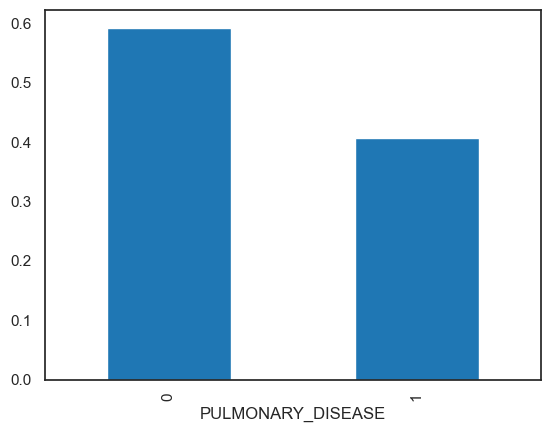

In [24]:
df['PULMONARY_DISEASE'].value_counts(normalize=True).plot(kind='bar')
plt.show()

Distribution of Target Variable

Interpretation:

0 (No Lung Cancer): 59.3% of patients

1 (Lung Cancer): 40.7% patients


The dataset appears to be roughly balanced between positive (YES) and negative (NO) cases of pulmonary disease, with a slight majority being negative casesnts

In [25]:
#Age Distribution
df['AGE'].value_counts()

AGE
64    110
76    110
78    108
55    107
37    106
66    106
74    106
50    105
57    104
63    100
80     98
73     97
46     97
54     97
58     97
83     96
62     96
33     96
40     96
51     96
52     95
84     95
61     95
53     95
65     94
70     93
82     92
69     91
59     91
41     91
32     90
31     90
49     89
68     89
42     88
35     88
30     87
34     87
47     86
44     86
38     85
43     85
48     84
67     84
81     83
75     81
79     81
39     79
71     77
56     73
77     71
45     71
36     70
72     69
60     67
Name: count, dtype: int64

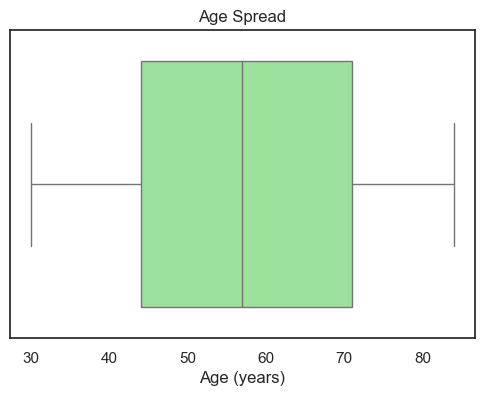

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='AGE', color='lightgreen')
plt.title('Age Spread')
plt.xlabel('Age (years)')
plt.show()

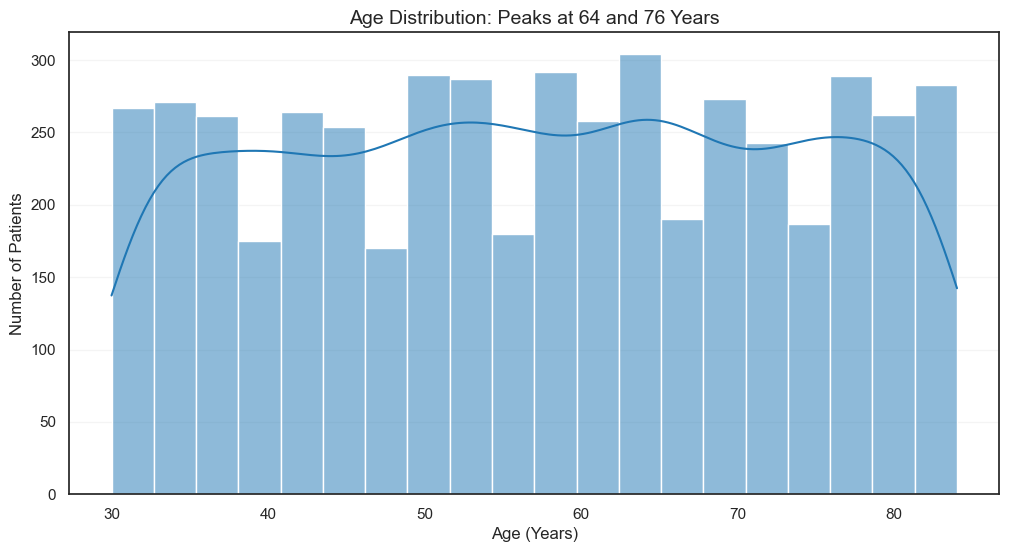

In [27]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='AGE', bins=20, kde=True, color='#1f77b4')
plt.title('Age Distribution: Peaks at 64 and 76 Years', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()

In [28]:
#transforming 'AGES' into clinically relevant categories
# Define bins and labels
bins = [0, 40, 60, 100]
labels = ['<40', '40-60', '60+']

# Create new binned column
df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=bins,
    labels=labels,
    include_lowest=True  # Ensures age=0 is included
)

In [29]:
# Verify groupings
print(df['AGE_GROUP'].value_counts().sort_index())

AGE_GROUP
<40       974
40-60    1804
60+      2222
Name: count, dtype: int64


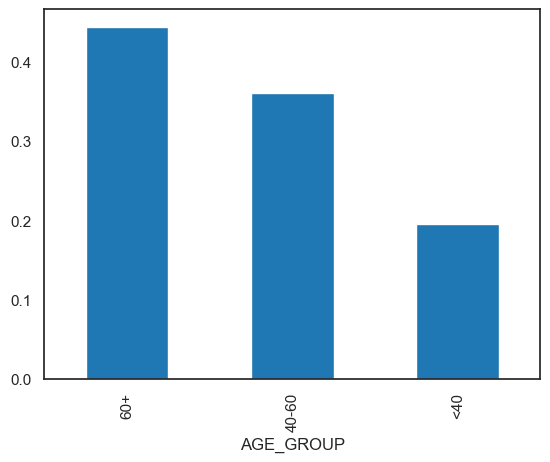

In [30]:
df['AGE_GROUP'].value_counts(normalize=True).plot(kind='bar')
plt.show()

## 2.2 Bivariate Analysis

In [31]:
df.groupby('PULMONARY_DISEASE').count()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,OXYGEN_LEVEL,AGE_GROUP
PULMONARY_DISEASE,,,,,,,,,,,,,,,,,,,
0,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963,2963
1,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037


In [32]:
df.groupby('GENDER').count()

,AGE,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE,OXYGEN_LEVEL,AGE_GROUP
GENDER,,,,,,,,,,,,,,,,,,,
0,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494,2494
1,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506,2506


In [33]:
df.groupby('AGE_GROUP', observed=False)['PULMONARY_DISEASE'].value_counts()

AGE_GROUP  PULMONARY_DISEASE
<40        0                     576
           1                     398
40-60      0                    1055
           1                     749
60+        0                    1332
           1                     890
Name: count, dtype: int64

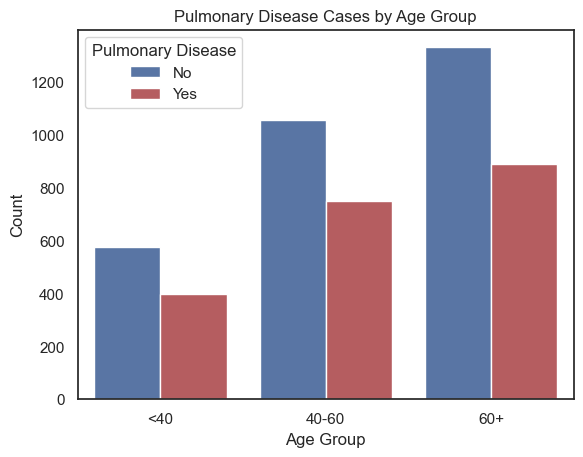

In [34]:
sns.countplot(data=df, x='AGE_GROUP', hue='PULMONARY_DISEASE', palette=['#4c72b0', '#c44e52'])
plt.title('Pulmonary Disease Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Pulmonary Disease', labels=['No', 'Yes'])
plt.show()

Interpretation: Heights show total patients per age group.

Colors split counts into cancer (1) vs. no cancer (0

The figure above shows the Pulmonary Disease seems more prevalent in older adults above 60. The dataset accross these three age groups show a similar ratio between partients with pulmonary disease and patients without pulmonary disease. This confirms that the ailment based on the age distribution within the age groups does not have a very strong correlation i.e., age is important however, not a key factor for diagnosing pulmonary disease even though this data shows older patients are the most diagnoised, other factors are expected to show a stronger causal correlation.).

In [35]:
#count comparison of gender and pulmonary disease
df.groupby('GENDER')['PULMONARY_DISEASE'].value_counts().unstack()

PULMONARY_DISEASE,0,1
GENDER,,
0,1473,1021
1,1490,1016


In [36]:
#probability of lung cancer based on gender
gender_prob = df.groupby('GENDER')['PULMONARY_DISEASE'].mean().reset_index()
gender_prob.columns = ['GENDER', 'CANCER_PROBABILITY']
print(gender_prob)

   GENDER  CANCER_PROBABILITY
0       0               0.409
1       1               0.405


In [37]:
df['GENDER_CATEGORY'] = df['GENDER'].replace({0: 'Male', 1: 'Female'})

In [38]:
df['GENDER_CATEGORY'].value_counts()

GENDER_CATEGORY
Female    2506
Male      2494
Name: count, dtype: int64

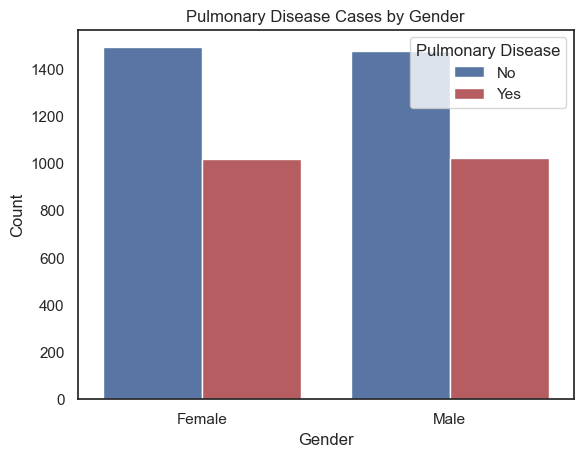

In [39]:
sns.countplot(data=df, x='GENDER_CATEGORY', hue='PULMONARY_DISEASE', palette=['#4c72b0', '#c44e52'])
plt.title('Pulmonary Disease Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Pulmonary Disease', labels=['No', 'Yes'])
plt.show()

Interpretation: Heights show total patients per gender category.

Colors split counts into cancer (1) vs. no cancer (0).

This data shows an even distribution between both genders in the diagnosis of pulmonary disease. According to (cite several papers), pulmonary disease is more prevalent in male than female, however, this data does not support this fact. It could be assumed that the participants for this research could have been careful selected based on other factors that may show more causal correlation than genetic expression of gender such as smoking, immune health and stress. This suspicion is supported by the near perfect balance between male and female participants, where in (cite facts) confirm that men have a stronger disposition to smoking and stress, therefore, expected to show more occurrence of a diagnosis.

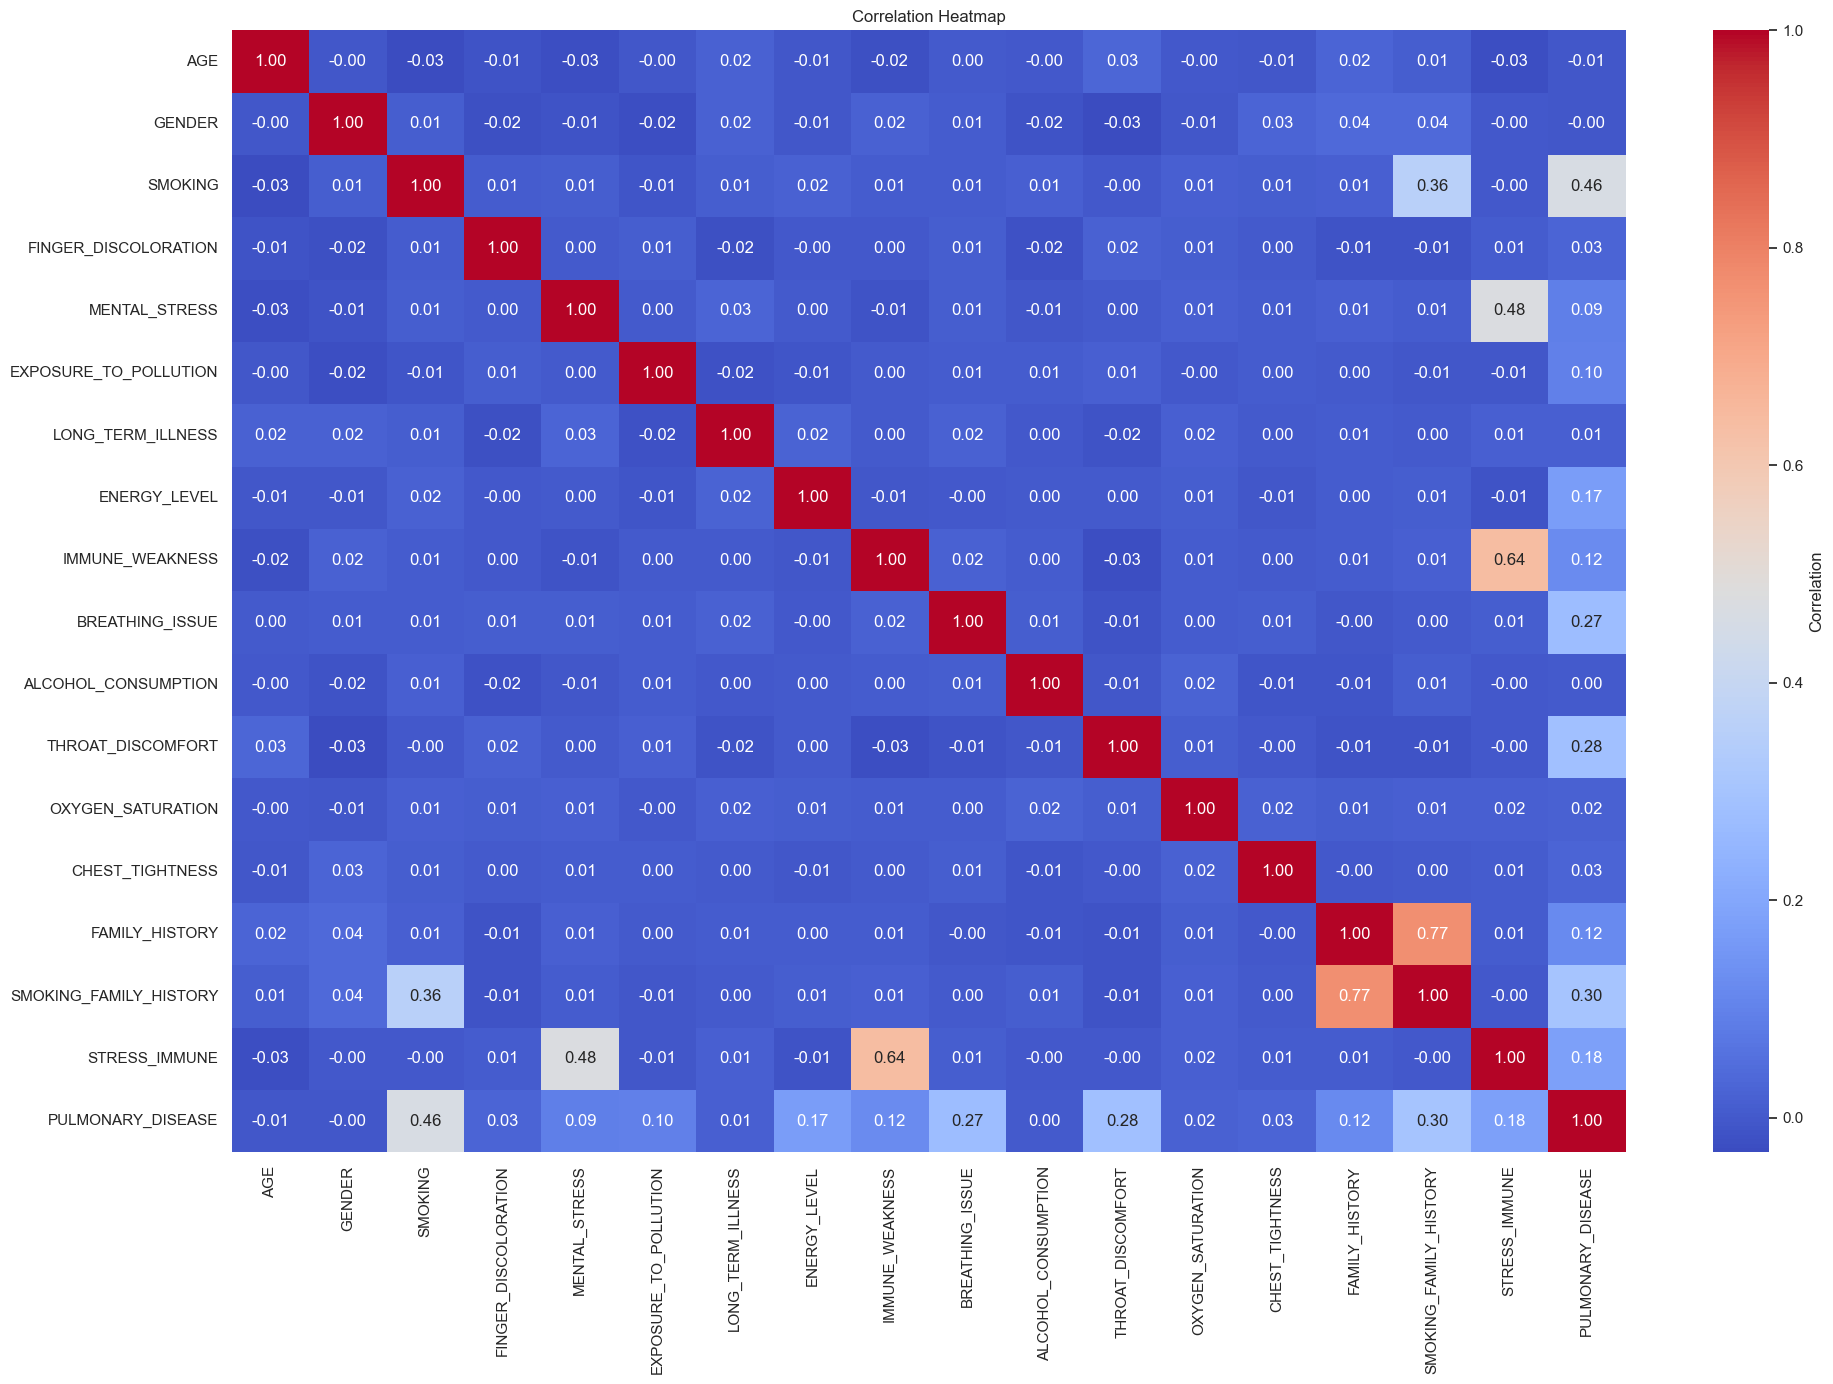

Features with Correlation > 0.03 with PULMONARY_DISEASE:


,Features,Correlation
0,SMOKING,0.461
1,SMOKING_FAMILY_HISTORY,0.302
2,THROAT_DISCOMFORT,0.284
3,BREATHING_ISSUE,0.270
4,STRESS_IMMUNE,0.181
5,ENERGY_LEVEL,0.171
6,IMMUNE_WEAKNESS,0.125
7,FAMILY_HISTORY,0.117
8,EXPOSURE_TO_POLLUTION,0.095
9,MENTAL_STRESS,0.089


In [40]:
# Reoder the dataframe so the target column is the last column on the dataset
df = df.reindex(columns=(list([a for a in df.columns if a != 'PULMONARY_DISEASE']) + ['PULMONARY_DISEASE']))

# Convert target variable to numeric
if df['PULMONARY_DISEASE'].dtype == object:
    df['PULMONARY_DISEASE'] = df['PULMONARY_DISEASE'].map({'NO': 0, 'YES': 1})

# Compute correlation matrix using only numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Extract correlations with the target variable
target_corr = corr_matrix['PULMONARY_DISEASE'].drop('PULMONARY_DISEASE')  # Drop self-correlation

# Filter features with correlation > 0.3
hm_pearson_corr_features = target_corr[target_corr > 0.03].sort_values(ascending=False)
hm_pearson_corr_features = pd.DataFrame({'Features': hm_pearson_corr_features.index, 'Correlation': hm_pearson_corr_features.values})

# Plot the heatmap
plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Display the filtered features and their correlation scores
print("Features with Correlation > 0.03 with PULMONARY_DISEASE:")
hm_pearson_corr_features

#### Display all non-numerical (categorical/object) columns and their unique values in df

In [41]:
non_numerical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in non_numerical_cols:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 40)

Column: OXYGEN_LEVEL
[1, 2, 0]
Categories (3, int64): [0 < 1 < 2]
----------------------------------------
Column: AGE_GROUP
['60+', '40-60', '<40']
Categories (3, object): ['<40' < '40-60' < '60+']
----------------------------------------
Column: GENDER_CATEGORY
['Female' 'Male']
----------------------------------------


In [42]:
# Ensure AGE_GROUP and GENDER_CATEGORY are categorical (support both spaced and underscored names)
age_order = ['<40', '40-60', '60+']
gender_order = ['Male', 'Female']

if 'AGE_GROUP' in df.columns:
    df['AGE_GROUP'] = pd.Categorical(df['AGE_GROUP'], categories=age_order, ordered=True)
elif 'AGE GROUP' in df.columns:
    df['AGE GROUP'] = pd.Categorical(df['AGE GROUP'], categories=age_order, ordered=True)

if 'GENDER_CATEGORY' in df.columns:
    df['GENDER_CATEGORY'] = pd.Categorical(df['GENDER_CATEGORY'], categories=gender_order)
elif 'GENDER CATEGORY' in df.columns:
    df['GENDER CATEGORY'] = pd.Categorical(df['GENDER CATEGORY'], categories=gender_order)

# Quick verification
print(df[[c for c in ['AGE_GROUP','GENDER_CATEGORY'] if c in df.columns]].dtypes)
print(df['AGE_GROUP'].value_counts(sort=False))
print(df['GENDER_CATEGORY'].value_counts())

AGE_GROUP          category
GENDER_CATEGORY    category
dtype: object
AGE_GROUP
<40       974
40-60    1804
60+      2222
Name: count, dtype: int64
GENDER_CATEGORY
Female    2506
Male      2494
Name: count, dtype: int64


100%|██████████| 10/10 [00:01<00:00,  7.34it/s]


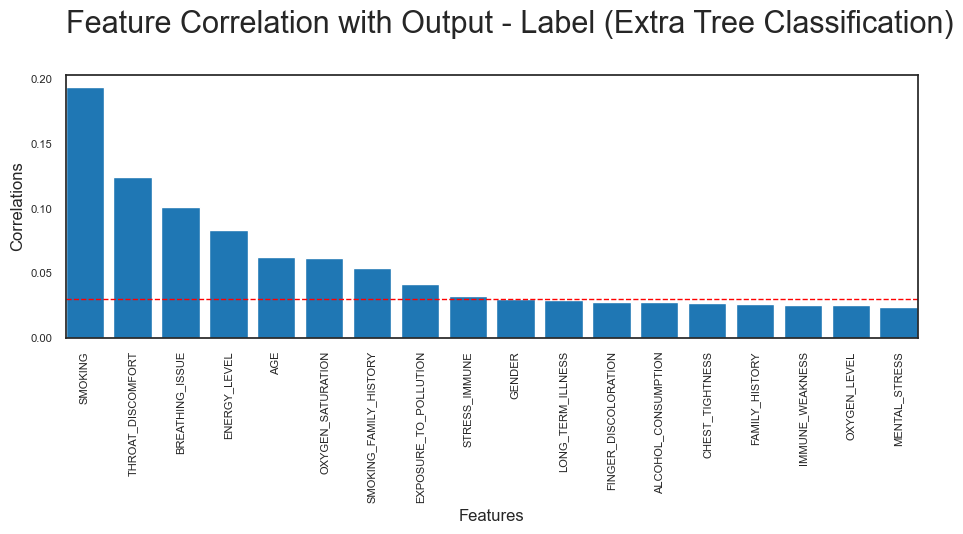

,Features,Correlation
0,SMOKING,0.194
1,THROAT_DISCOMFORT,0.125
2,BREATHING_ISSUE,0.101
3,ENERGY_LEVEL,0.084
4,AGE,0.063
5,OXYGEN_SATURATION,0.062
6,SMOKING_FAMILY_HISTORY,0.054
7,EXPOSURE_TO_POLLUTION,0.042
8,STRESS_IMMUNE,0.033
9,GENDER,0.030


In [43]:
%matplotlib inline

X = df.drop(['PULMONARY_DISEASE','AGE_GROUP', 'GENDER_CATEGORY'], axis=1)
y = df['PULMONARY_DISEASE'].reset_index(drop=True)

def extra_tree_classifier(feature_count, X, y):
    model = ExtraTreesClassifier()
    chunksize = 500
    
    for i in tqdm(range(0, len(df), chunksize)):
        x_chunk = X.iloc[i:i+chunksize]
        y_chunk = y.iloc[i:i+chunksize]
    
        model.fit(x_chunk, y_chunk)

    feat_importances = pd.Series(model.feature_importances_, index = X.columns)
    correlations = feat_importances.nlargest(X.shape[1]+1)

    corr_df = pd.DataFrame(correlations).reset_index()
    corr_df.columns = ['Features', 'Correlation']
    
    # Select top features based on absolute correlation
    df_output = corr_df.nlargest(feature_count, "Correlation")
    threshold = df_output['Correlation'][len(df_output)-1]
    
    fig, ax = plt.subplots(1, figsize=(9.5,5.5))
    
    ax.bar(corr_df['Features'], corr_df['Correlation'], align="center")        
    ax.axhline(y=threshold, color='r', linestyle='dashed', linewidth=1, label=f'Threshold: {threshold}')  # Add line
    plt.title('Feature Correlation with Output - Label (Extra Tree Classification)\n', loc='left', fontsize=22)
    plt.xlabel('Features')
    plt.yticks(fontsize=8)
    plt.xticks(rotation = 90, fontsize=8)
    plt.ylabel('Correlations')
    plt.tight_layout()
    plt.margins(x=0)
    plt.show()

    return df_output

ext_tree_selected_features = extra_tree_classifier(10, X, y)
ext_tree_selected_features

In [44]:
def correlation_with_target(X, y, method="spearman", feature_count=10):
    """
    Compute correlations between each feature in X and the target column y.
    
    Parameters:
        X (pd.DataFrame): DataFrame containing feature columns.
        y (pd.Series or array-like): Target column (categorical integer encoding).
        method (str): Correlation method - "spearman".
        threshold (float): Minimum correlation value to include in the plot.
    
    Returns:
        pd.DataFrame: DataFrame containing features and their correlation values.
    """
    # Ensure y is a pandas Series for compatibility
    if not isinstance(y, pd.Series):
        y = pd.Series(y, name="Label")
    
    # Compute correlations for each feature in X with y
    correlations = []
    for feature in tqdm(X.columns):
        corr, _ = stats.spearmanr(X[feature], y)
        
        correlations.append((feature, abs(corr)))  # Use absolute correlation
    
    # Convert to DataFrame
    corr_df = pd.DataFrame(correlations, columns=["Features", "Correlation"])

    corr_df = corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)

    threshold_feature_score = corr_df['Correlation'][feature_count - 1]
    
    # Select top features based on absolute correlation
    top_features = corr_df.nlargest(feature_count, "Correlation")
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.bar(corr_df["Features"], corr_df["Correlation"], align="center")
    plt.title(f"Feature Correlation with Target ({method.capitalize()} Method)", fontsize=22)
    plt.axhline(y=threshold_feature_score, color='r', linestyle='dashed', linewidth=1, label=f'Threshold: {threshold_feature_score}')  # Add line
    plt.xlabel("Features", fontsize=12)
    plt.xticks(rotation=90, fontsize=10)
    plt.ylabel("Correlation",  fontsize=12)
    plt.tight_layout()
    plt.margins(x=0)
    plt.show()
    
    return top_features

100%|██████████| 18/18 [00:00<00:00, 740.28it/s]


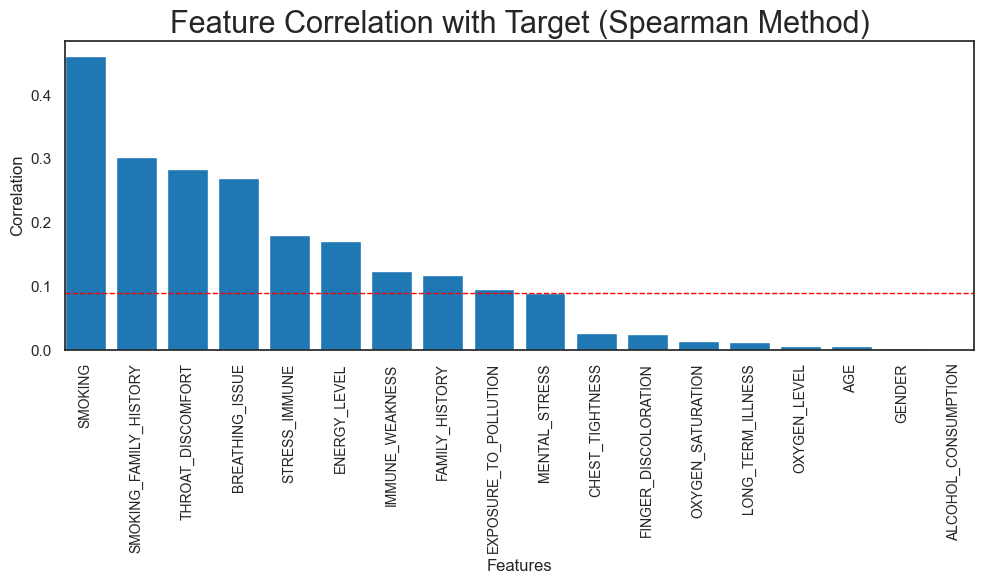

,Features,Correlation
0,SMOKING,0.461
1,SMOKING_FAMILY_HISTORY,0.302
2,THROAT_DISCOMFORT,0.284
3,BREATHING_ISSUE,0.270
4,STRESS_IMMUNE,0.181
5,ENERGY_LEVEL,0.171
6,IMMUNE_WEAKNESS,0.125
7,FAMILY_HISTORY,0.117
8,EXPOSURE_TO_POLLUTION,0.095
9,MENTAL_STRESS,0.089


In [45]:
spearman_selected_features = correlation_with_target(X, y, feature_count=10)
spearman_selected_features

#### IDENTIFY NON-LINEAR RELATIONS BETWEEN INTERACTION-PAIRS AND 'PULMONARY-DISEASE'

This section seeks to identify non-linear relations between features with strong linear correlations and the target variable 'PULMONARY_DISEASE'. The features with high correlations are shown in the heatmap above as features with strong correlations (above 0.3):
1. SMOKING × SMOKING_FAMILY_HISTORY: Correlation = 0.36
2. IMMUNE_WEAKNESS × STRESS_IMMUNE: Correlation = 0.64
3. STRESS_IMMUNE × MENTAL_STRESS: Correlation = 0.48
4. FAMILY_HISTORY × SMOKING_FAMILY_HISTORY: Correlation = 0.77

These features with strong correlations are termed 'interaction pairs', and each pair are correlated to the target variable to identify non-linear relations between the target variable and each feature in a pair.

#### Define Function to plot interaction pairs on a Bar Plot using seaborn and pyplot library

In [46]:
def plot_barplot(feat1, feat2):
    plt.figure(figsize=(8, 6))
    sns.barplot(x=feat1, y='PULMONARY_DISEASE', hue=feat2, data=df)
    plt.title(f'Interaction Effect of {feat1} and {feat2} on PULMONARY_DISEASE')
    plt.ylabel('Proportion with PULMONARY_DISEASE (Mean)')
    plt.xlabel(f'{feat1} (0 = No, 1 = Yes)')
    plt.legend(title=f'{feat2} (0 = No, 1 = Yes)')
    plt.show()

#### Calculate correlation of correction pairs and target variable

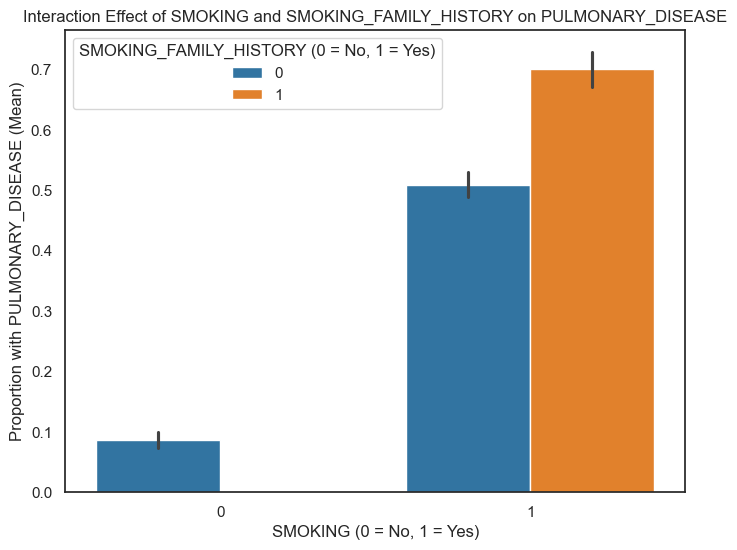

In [47]:
# Assuming df is already loaded and PULMONARY_DISEASE is numeric (0/1)
# If not, convert it:
if df['PULMONARY_DISEASE'].dtype == object:
    df['PULMONARY_DISEASE'] = df['PULMONARY_DISEASE'].map({'NO': 0, 'YES': 1})

# List of non-target feature pairs with strong correlations (> 0.3)
interaction_pairs = [
    ('SMOKING', 'SMOKING_FAMILY_HISTORY'),
    ('IMMUNE_WEAKNESS', 'STRESS_IMMUNE'),
    ('STRESS_IMMUNE', 'MENTAL_STRESS'),
    ('FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY')
]

# Compute interaction terms and their correlations with PULMONARY_DISEASE
interaction_results = []
for feat1, feat2 in interaction_pairs:
    interaction_term = f"{feat1}_x_{feat2}"
    df[interaction_term] = df[feat1] * df[feat2]
    corr, p_value = stats.pearsonr(df[interaction_term], df['PULMONARY_DISEASE'])
    interaction_results.append({
        'Interaction': interaction_term,
        'Correlation': corr,
        'P-Value': p_value,
        'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

# Convert results to a DataFrame and sort by correlation
interaction_df = pd.DataFrame(interaction_results)
interaction_df = interaction_df.sort_values(by='Correlation', ascending=False)

# Visualize all interactions
feat1, feat2 = interaction_pairs[0] 
plot_barplot(feat1, feat2)
# print(interaction_pairs[0])

The grouped barplot above shows the correlation between the interaction-pair 'smoking' and 'smoking_family_history', and the target variable 'Pulmonary_Disease'. The barplot shows the likelihood of being diagnosed with 'pulmonary_disease' based on the presence of a feature within the interaction-pair in a patient, as analysed from the dataset. This means the barplot displays the result computed from ascertaining the ratio of patients within the dataset whom have a presence or non-presence of a features within an interaction pair and whether it leads to 'pulmonary_disease'. This calculation tranlates to the likelihood of being diagnosed (risk exposure) with pulmonary disease based on the combination of features you get within an interaction pair.

The figure above shows the risk exposure of patients based on how they smoke and the family history of smoking. The X axis represents the first feature in an interaction pair which could be considered the primary feature, and the hue in the legend is the second feature in the interaction pair which could be considered the secondary feature. When a patient doesn't smoke (Smoking: 0=No) on the left of the X-axis, and the patient also doesn't have a history of smoking in their family (Smoking_family_history: 0:No) then the risk of being diagnosed with pulmonary disease is below 10% (i.e., 0.1 on the y-axis). This analysis doesn't factor in other features of that given patient, just the features in the interaction pair.

The barplot above shows the interaction effect of 'Smoking' and 'Smoking_Family_History' on 'Pulmonary_Disease', has the highest risk (~70% or 0.7 on Y-axis) when a patient smokes and has a history of smoking in the family. This non-linear relationship exposes a higher risk factor than the individual risk factor of either 'Smoking' at 46% and 'Smoking_family_history' at 30% according to the heatmap above. This interaction is not derived by summing the risk factors of individuals features in an interaction pair as would be made more evident in the subsequent interaction pair analysis.

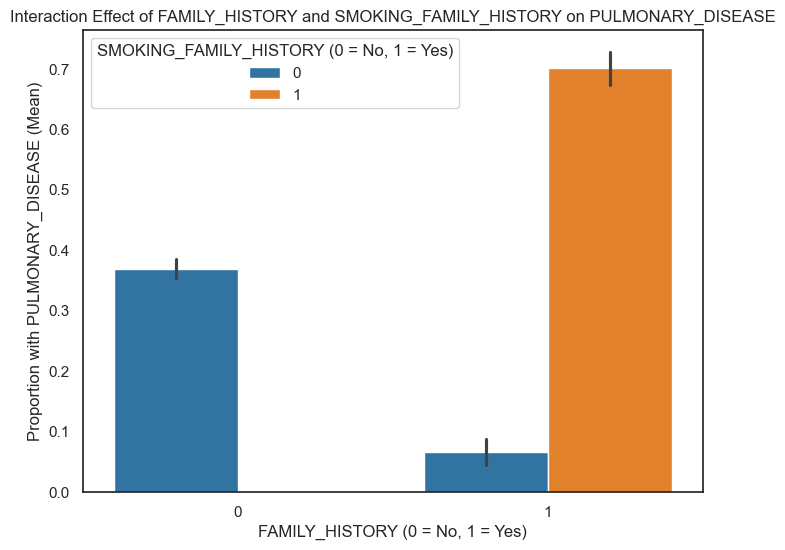

In [48]:
# Visualize next interactions
feat1, feat2 = interaction_pairs[3] 
plot_barplot(feat1, feat2)

The figure above shows that a patient has a high risk (~70% with risk ranging between 74% and 66%) of being diagnosed with pulmonary disease. The features in this interaction pair have individual risk factor of 12% for family history and 30% for smoking family history of being diagnosed with pulmonary disease based on linear correlation, which combined are below the ~70% risk exposure of the interation pair. The similarity between the correlation of the interaction pair FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY and SMOKING_x_SMOKING_FAMILY_HISTORY shows SMOKING_FAMILY_HISTORY as a strong determinant of achieving ~70% risk when it interacts with SMOKING or FAMILY_HISTORY, given that the correlation between SMOKING and FAMILY_HISTORY is 1% according to the heatmap above, therefore, we can intuite that the denominator SMOKING_FAMILY_HISTORY in both interation pair is a strong determinant.

These insights are validated because the heatmap default analysis method is the pearsonr algorithm, same algorithm employed by stats class in the scipy library for calculating the correlation and p-value between interaction-pairs and target variable.

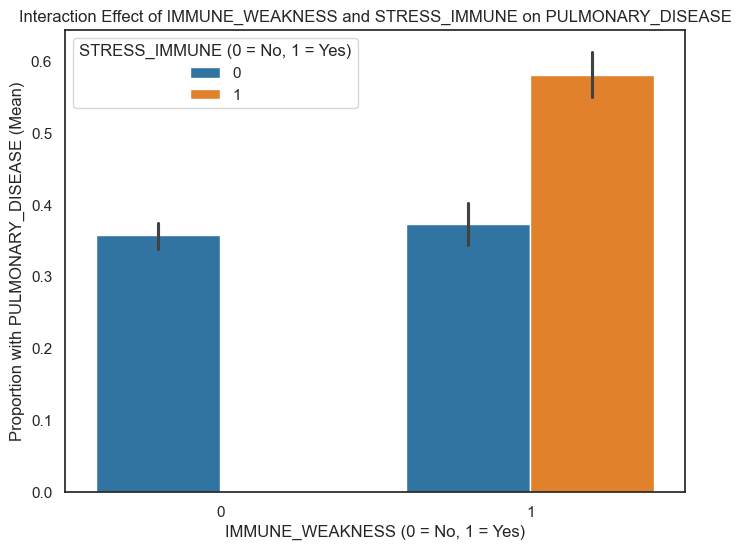

In [49]:
# Visualize next interactions
feat1, feat2 = interaction_pairs[1] 
plot_barplot(feat1, feat2)

The figure above shows that a patient has a high risk (~57% with risk ranging between 54% and 64%) of being diagnosed with pulmonary disease. The features in this interaction pair have individual risk factor of 12% for immune weakness and 18% for stress immune, which combined are below the ~57% risk exposure of the interation pair. This non-linear relationship provides insights not visible within the scope of linear correlations as shown in the heatmap above.

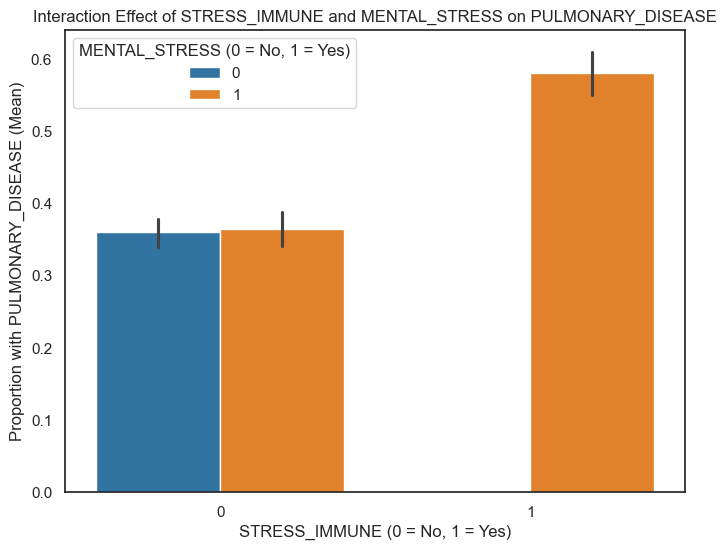

In [50]:
# Visualize all interactions
feat1, feat2 = interaction_pairs[2] 
plot_barplot(feat1, feat2)

The figure above shows that a patient has a high risk (~57% with risk ranging between 54% and 64%) of being diagnosed with pulmonary disease. The features in this interaction pair have individual risk factor of 9% for mental stress and 18% for stress immune, which combined are below the ~57% risk exposure of the interation pair. The similarity between the correlation of the interaction pair STRESS_IMMUNE_x_MENTAL_STRESS and IMMUNE_WEAKNESS_x_STRESS_IMMUNE shows STRESS_IMMUNE as a strong determinant of achieving ~57% risk when it interacts with IMMUNE_WEAKNESS or MENTAL_STRESS, given that the correlation between IMMUNE_WEAKNESS and MENTAL_STRESS is 1% according to the heatmap above, therefore, we can intuite that the denominator STRESS_IMMUNE in both interation pair is a strong determinant.

In [51]:
# Display the results
print("Correlation of Interaction Terms with PULMONARY_DISEASE:")
interaction_df.reset_index(drop=True)

Correlation of Interaction Terms with PULMONARY_DISEASE:


,Interaction,Correlation,P-Value,Significant (p < 0.05)
0,SMOKING_x_SMOKING_FAMILY_HISTORY,0.302,0.000,Yes
1,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,0.302,0.000,Yes
2,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,0.181,0.000,Yes
3,STRESS_IMMUNE_x_MENTAL_STRESS,0.181,0.000,Yes


The table above shows the correlation between each interaction pair as a factor (whether present or not) and the target variable, for determining a patients likelihood of pulmonary diagnosis. The p-value is used to ascertain the significance of each interaction pair which conventially is accepted at below 0.05

## Split Dataset into Training and Validation Set

In [52]:
df.shape

(5000, 25)

In [53]:
X = df.drop(['PULMONARY_DISEASE'], axis=1)
y = df['PULMONARY_DISEASE']

X[["AGE_GROUP", "GENDER_CATEGORY"]] = X[["AGE_GROUP", "GENDER_CATEGORY"]].apply(lambda col: col.astype('category').cat.codes)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,...,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,OXYGEN_LEVEL,AGE_GROUP,GENDER_CATEGORY,SMOKING_x_SMOKING_FAMILY_HISTORY,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,STRESS_IMMUNE_x_MENTAL_STRESS,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY
1646,64,1,0,1,1,1,0,50.226,1,0,...,0,0,1,1,2,1,0,1,1,0
2041,36,0,0,1,1,1,0,54.945,1,1,...,1,0,1,1,0,0,0,1,1,0
2842,30,0,0,1,1,1,0,37.114,1,1,...,0,0,1,1,0,0,0,1,1,0
2198,31,0,1,1,1,1,1,40.638,1,1,...,1,1,1,2,0,0,1,1,1,1
644,53,0,1,0,0,1,0,59.515,1,1,...,0,0,0,1,1,0,0,0,0,0


## Scale Data Using StandardScaler

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Important: Save scaler for deployment

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### Data Engineering - Resample Dataset to fix Imbalance (SMOTE)

In [115]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Class distribution before SMOTE\n: {y_train.value_counts()}")
print(f"\nClass distribution after SMOTE\n: {y_train_bal.value_counts()}")

X_test_bal, y_test_bal = smote.fit_resample(X_test_scaled, y_test)

print(f"Class distribution before SMOTE\n: {y_test.value_counts()}")
print(f"\nClass distribution after SMOTE\n: {y_test_bal.value_counts()}")

Class distribution before SMOTE
: PULMONARY_DISEASE
0    2370
1    1630
Name: count, dtype: int64

Class distribution after SMOTE
: PULMONARY_DISEASE
0    2370
1    2370
Name: count, dtype: int64
Class distribution before SMOTE
: PULMONARY_DISEASE
0    593
1    407
Name: count, dtype: int64

Class distribution after SMOTE
: PULMONARY_DISEASE
0    593
1    593
Name: count, dtype: int64


Here the Synthetic Minority Oversampling Technique (SMOTE) is used to balance the imbalance in the dataset. It upsampled the number of occurence of patients diagnosed with pulmonary disease.

#### Balanced Input Data as Dataframe

In [ ]:
X_train_bal_df = pd.DataFrame(X_train_bal, columns=df.drop("PULMONARY_DISEASE", axis=1).columns)
X_train_bal_df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,...,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,OXYGEN_LEVEL,AGE_GROUP,GENDER_CATEGORY,SMOKING_x_SMOKING_FAMILY_HISTORY,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,STRESS_IMMUNE_x_MENTAL_STRESS,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY
0,0.427,1.003,-1.407,0.808,0.920,0.954,-0.888,-0.602,1.229,-1.972,...,-0.664,-0.509,1.927,-0.478,0.983,1.003,-0.509,1.927,1.927,-0.509
1,-1.356,-0.997,-1.407,0.808,0.920,0.954,-0.888,-0.011,1.229,0.507,...,1.507,-0.509,1.927,-0.478,-1.650,-0.997,-0.509,1.927,1.927,-0.509
2,-1.738,-0.997,-1.407,0.808,0.920,0.954,-0.888,-2.246,1.229,0.507,...,-0.664,-0.509,1.927,-0.478,-1.650,-0.997,-0.509,1.927,1.927,-0.509
3,-1.674,-0.997,0.711,0.808,0.920,0.954,1.126,-1.804,1.229,0.507,...,1.507,1.963,1.927,1.685,-1.650,-0.997,1.963,1.927,1.927,1.963
4,-0.273,-0.997,0.711,-1.238,-1.087,0.954,-0.888,0.562,1.229,0.507,...,-0.664,-0.509,-0.519,-0.478,-0.334,-0.997,-0.509,-0.519,-0.519,-0.509


In [118]:
X_test_bal_df = pd.DataFrame(X_test_bal, columns=df.drop("PULMONARY_DISEASE", axis=1).columns)
X_test_bal_df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,...,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,OXYGEN_LEVEL,AGE_GROUP,GENDER_CATEGORY,SMOKING_x_SMOKING_FAMILY_HISTORY,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,STRESS_IMMUNE_x_MENTAL_STRESS,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY
0,-0.273,-0.997,0.711,0.808,0.920,-1.049,1.126,-0.141,-0.814,-1.972,...,-0.664,-0.509,-0.519,-0.478,-0.334,-0.997,-0.509,-0.519,-0.519,-0.509
1,-1.356,1.003,0.711,0.808,0.920,-1.049,-0.888,0.256,1.229,0.507,...,1.507,1.963,1.927,1.685,-1.650,1.003,1.963,1.927,1.927,1.963
2,-0.528,1.003,0.711,-1.238,0.920,-1.049,-0.888,0.260,-0.814,0.507,...,-0.664,-0.509,-0.519,-0.478,-0.334,1.003,-0.509,-0.519,-0.519,-0.509
3,1.000,-0.997,0.711,-1.238,0.920,-1.049,1.126,-1.888,-0.814,-1.972,...,-0.664,-0.509,-0.519,-0.478,0.983,-0.997,-0.509,-0.519,-0.519,-0.509
4,-1.419,1.003,0.711,-1.238,0.920,-1.049,-0.888,1.413,-0.814,0.507,...,-0.664,-0.509,-0.519,-0.478,-1.650,1.003,-0.509,-0.519,-0.519,-0.509


### Feature Selection

In [57]:
def rank_features_for_selection(selected_features_list):
    """
    Aggregate and rank features from multiple feature selection methods.

    Parameters:
        selected_features_list (list of pd.DataFrame): List of DataFrames containing "Features" and "Data" columns
        from different feature analysis methods.

    Returns:
        pd.DataFrame: DataFrame with features ranked by their cumulative average score across methods.
    """
    # Initialize an empty DataFrame to hold combined scores
    combined_df = pd.DataFrame()

    # Merge all selected_features DataFrames on "Features" column
    for i, df in enumerate(selected_features_list):
        # Rename the "Data" column to indicate the method (e.g., "Data_1", "Data_2", ...)
        if i == 0:
            df_renamed = df.rename(columns={"Correlation": f"HM_Peasonr"})
        elif i == 1:
            df_renamed = df.rename(columns={"Correlation": f"Spearman"})
        else: 
            df_renamed = df.rename(columns={"Correlation": f"Ext_Tree_Clsfr"})
            
        # df_renamed = df.rename(columns={"data": f"Data_{i+1}"})
        if combined_df.empty:
            combined_df = df_renamed
        else:
            combined_df = pd.merge(combined_df, df_renamed, on="Features", how="outer")
    
    # Fill missing scores with 0
    combined_df.fillna(0, inplace=True)

    # Compute the average score across methods
    data_columns = [col for col in combined_df.columns if col != "Features" and col != 'Average_Score']
    combined_df["Average_Score"] = combined_df[data_columns].mean(axis=1)

    # Sort by the average score in descending order
    ranked_features = combined_df.sort_values(by="Average_Score", ascending=False).reset_index(drop=True)
    
    return ranked_features

In [58]:
ranked_features = rank_features_for_selection([hm_pearson_corr_features, spearman_selected_features, ext_tree_selected_features])
selected_features = ranked_features[:10] # Select the top 15 features based on their average ranking
ranked_features

,Features,HM_Peasonr,Spearman,Ext_Tree_Clsfr,Average_Score
0,SMOKING,0.461,0.461,0.194,0.372
1,THROAT_DISCOMFORT,0.284,0.284,0.125,0.231
2,SMOKING_FAMILY_HISTORY,0.302,0.302,0.054,0.220
3,BREATHING_ISSUE,0.270,0.270,0.101,0.214
4,ENERGY_LEVEL,0.171,0.171,0.084,0.142
5,STRESS_IMMUNE,0.181,0.181,0.033,0.132
6,IMMUNE_WEAKNESS,0.125,0.125,0.000,0.083
7,FAMILY_HISTORY,0.117,0.117,0.000,0.078
8,EXPOSURE_TO_POLLUTION,0.095,0.095,0.042,0.077
9,MENTAL_STRESS,0.089,0.089,0.000,0.060


In [59]:
X_train_bal.shape

(4740, 24)

In [60]:
y_train_bal.shape

(4740,)

#### Merge the balanced dataframes (X & y) vertically

In [61]:
bal_train_df = pd.concat([pd.DataFrame(X_train_bal, columns=df.drop('PULMONARY_DISEASE', axis=1).columns), y_train_bal.reset_index(drop=True)], axis=1)
# bal_train_df['PULMONARY_DISEASE'] = bal_train_df['PULMONARY_DISEASE'].astype(float)
bal_train_df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,...,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,OXYGEN_LEVEL,AGE_GROUP,GENDER_CATEGORY,SMOKING_x_SMOKING_FAMILY_HISTORY,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,STRESS_IMMUNE_x_MENTAL_STRESS,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,PULMONARY_DISEASE
0,0.427,1.003,-1.407,0.808,0.920,0.954,-0.888,-0.602,1.229,-1.972,...,-0.509,1.927,-0.478,0.983,1.003,-0.509,1.927,1.927,-0.509,0
1,-1.356,-0.997,-1.407,0.808,0.920,0.954,-0.888,-0.011,1.229,0.507,...,-0.509,1.927,-0.478,-1.650,-0.997,-0.509,1.927,1.927,-0.509,0
2,-1.738,-0.997,-1.407,0.808,0.920,0.954,-0.888,-2.246,1.229,0.507,...,-0.509,1.927,-0.478,-1.650,-0.997,-0.509,1.927,1.927,-0.509,0
3,-1.674,-0.997,0.711,0.808,0.920,0.954,1.126,-1.804,1.229,0.507,...,1.963,1.927,1.685,-1.650,-0.997,1.963,1.927,1.927,1.963,1
4,-0.273,-0.997,0.711,-1.238,-1.087,0.954,-0.888,0.562,1.229,0.507,...,-0.509,-0.519,-0.478,-0.334,-0.997,-0.509,-0.519,-0.519,-0.509,1


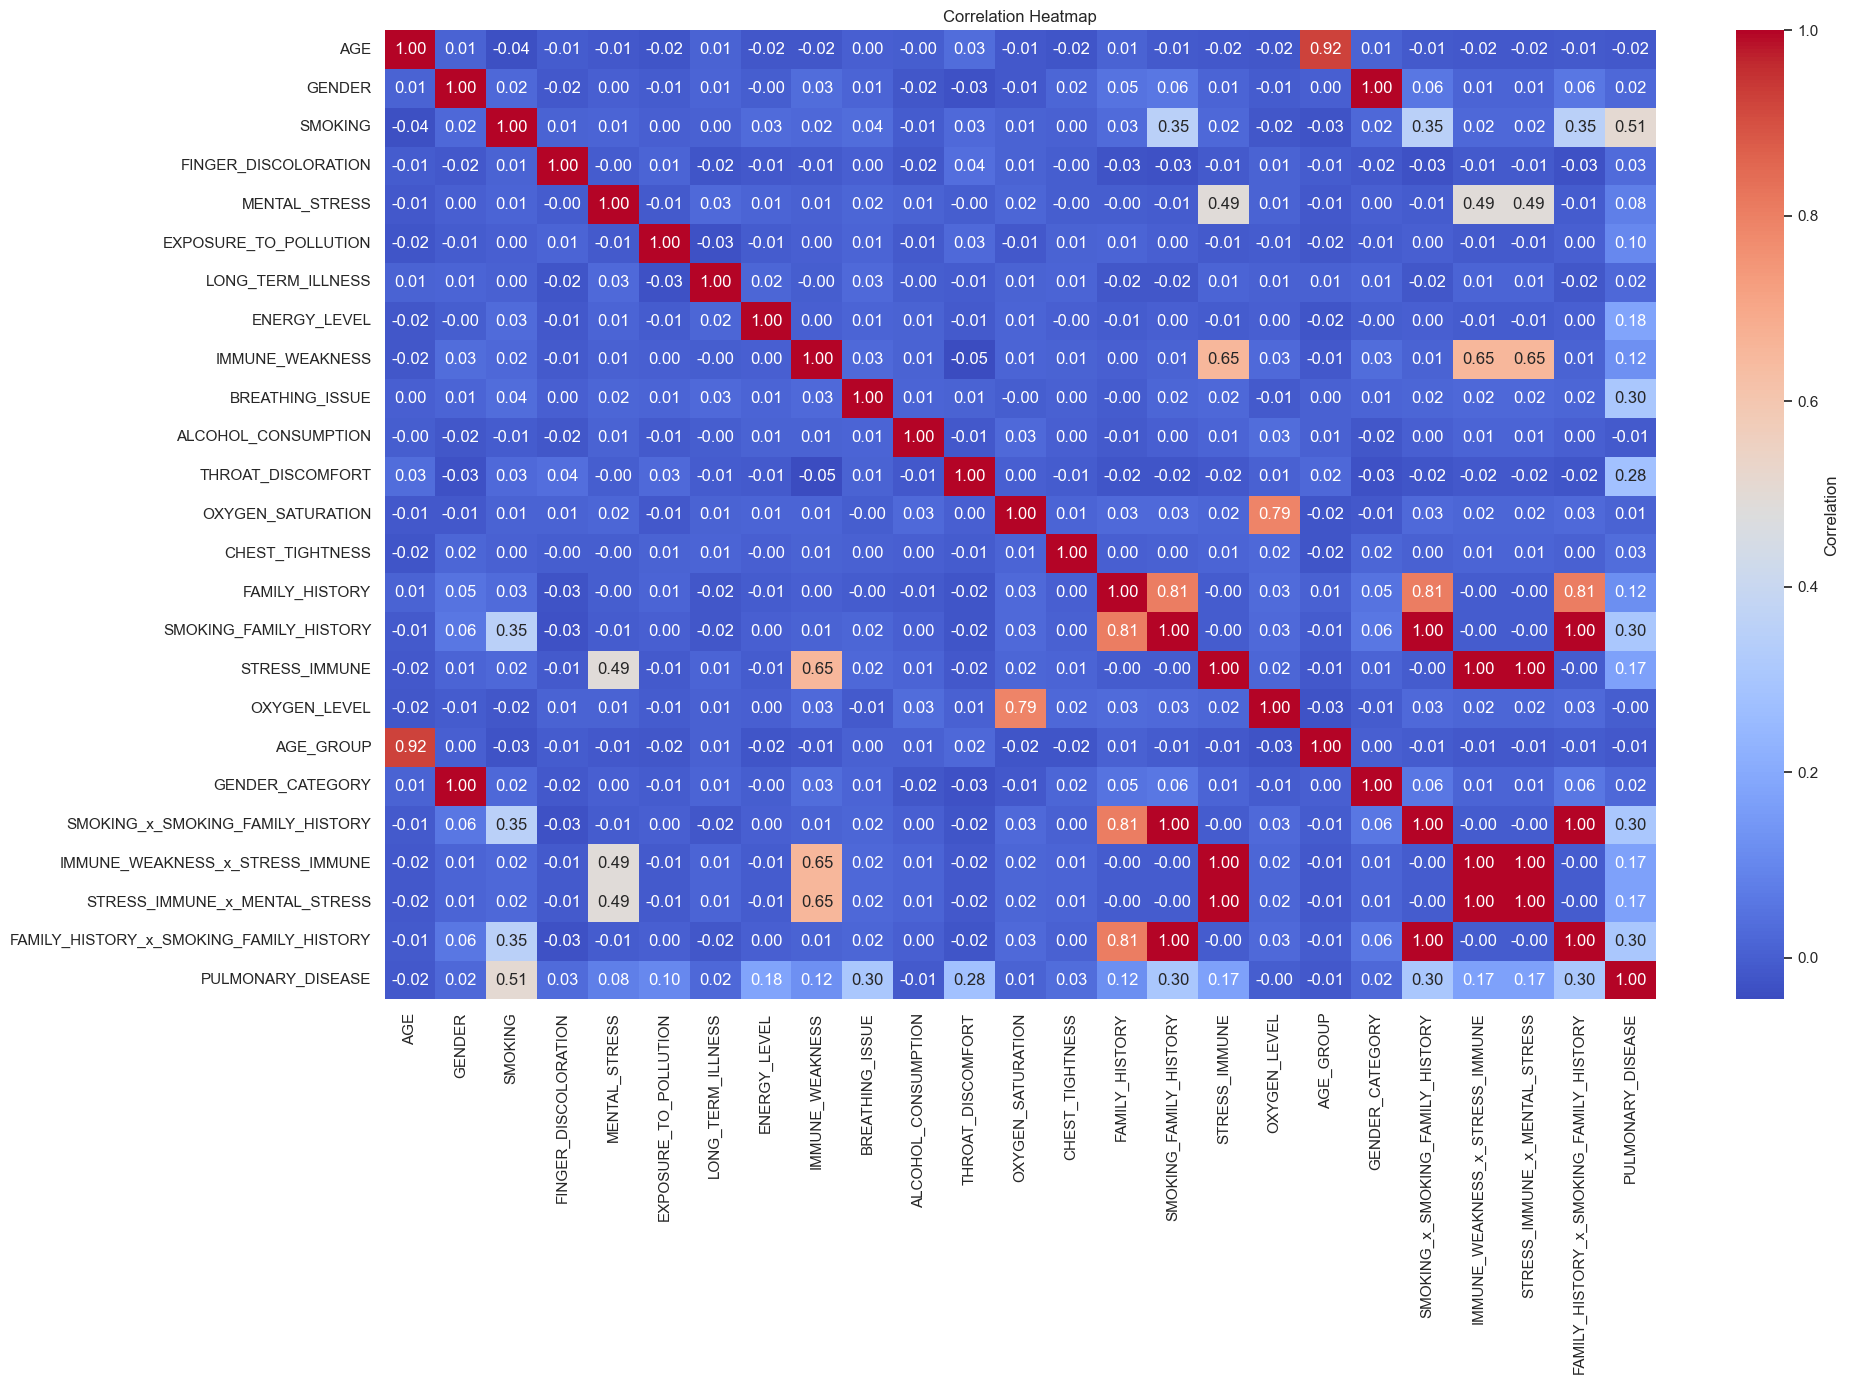

Features with Correlation > 0.03 with PULMONARY_DISEASE:


,Features,Correlation
0,SMOKING,0.507
1,BREATHING_ISSUE,0.304
2,SMOKING_FAMILY_HISTORY,0.303
3,SMOKING_x_SMOKING_FAMILY_HISTORY,0.303
4,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,0.303
5,THROAT_DISCOMFORT,0.280
6,ENERGY_LEVEL,0.181
7,STRESS_IMMUNE,0.172
8,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,0.172
9,STRESS_IMMUNE_x_MENTAL_STRESS,0.172


In [62]:
# Compute correlation matrix
bal_train_corr_matrix = bal_train_df.corr()

# Extract correlations with the target variable
bal_train_target_corr = bal_train_corr_matrix['PULMONARY_DISEASE'].drop('PULMONARY_DISEASE')  # Drop self-correlation

# Filter features with correlation > 0.3
bal_train_hm_pearson_corr_features = bal_train_target_corr[bal_train_target_corr > 0.03].sort_values(ascending=False)
bal_train_hm_pearson_corr_features = pd.DataFrame({'Features': bal_train_hm_pearson_corr_features.index, 'Correlation': bal_train_hm_pearson_corr_features.values})

# Plot the heatmap
plt.figure(figsize=(20, 14))
sns.heatmap(bal_train_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Display the filtered features and their correlation scores
print("Features with Correlation > 0.03 with PULMONARY_DISEASE:")
bal_train_hm_pearson_corr_features

100%|██████████| 10/10 [00:01<00:00,  7.21it/s]


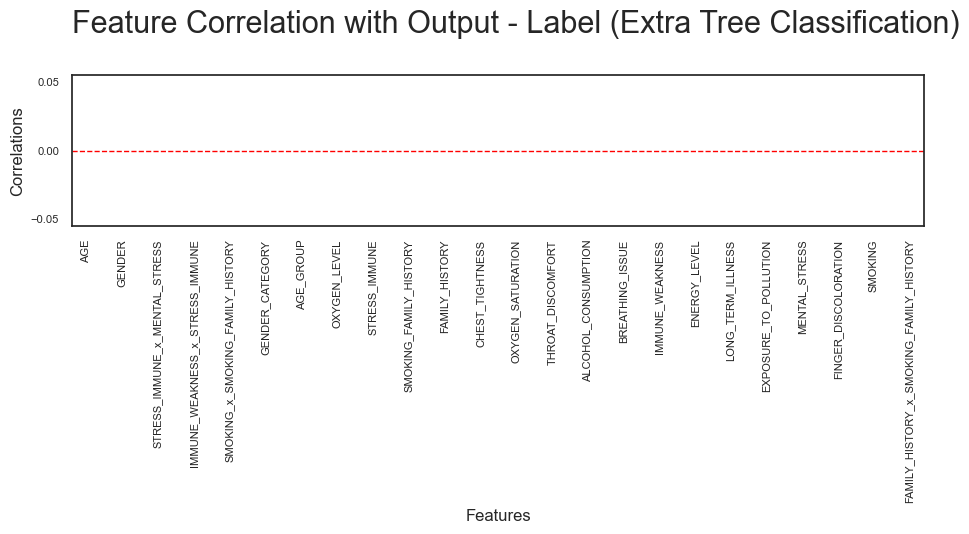

,Features,Correlation
0,AGE,0.000
1,GENDER,0.000
2,STRESS_IMMUNE_x_MENTAL_STRESS,0.000
3,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,0.000
4,SMOKING_x_SMOKING_FAMILY_HISTORY,0.000
5,GENDER_CATEGORY,0.000
6,AGE_GROUP,0.000
7,OXYGEN_LEVEL,0.000
8,STRESS_IMMUNE,0.000
9,SMOKING_FAMILY_HISTORY,0.000


In [63]:
bal_df_ext_tree_selected_features = extra_tree_classifier(15, bal_train_df.drop(['PULMONARY_DISEASE'], axis=1), bal_train_df['PULMONARY_DISEASE'])
bal_df_ext_tree_selected_features

100%|██████████| 24/24 [00:00<00:00, 656.24it/s]


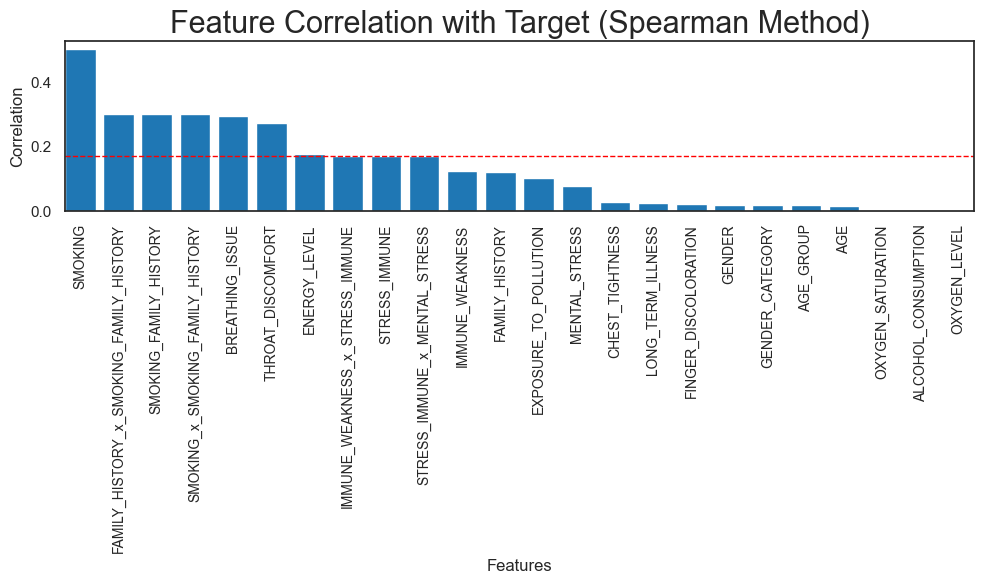

,Features,Correlation
0,SMOKING,0.504
1,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,0.303
2,SMOKING_FAMILY_HISTORY,0.303
3,SMOKING_x_SMOKING_FAMILY_HISTORY,0.303
4,BREATHING_ISSUE,0.296
5,THROAT_DISCOMFORT,0.276
6,ENERGY_LEVEL,0.179
7,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,0.172
8,STRESS_IMMUNE,0.172
9,STRESS_IMMUNE_x_MENTAL_STRESS,0.172


In [64]:
bal_df_spearman_selected_features = correlation_with_target(bal_train_df.drop(['PULMONARY_DISEASE'], axis=1), bal_train_df['PULMONARY_DISEASE'], feature_count=10)
bal_df_spearman_selected_features

In [65]:
bal_df_ranked_features = rank_features_for_selection([bal_train_hm_pearson_corr_features, bal_df_spearman_selected_features, bal_df_ext_tree_selected_features])
bal_df_selected_features = bal_df_ranked_features[:15] # Select the top 15 features based on their average ranking
bal_df_ranked_features

,Features,HM_Peasonr,Spearman,Ext_Tree_Clsfr,Average_Score
0,SMOKING,0.507,0.504,0.000,0.337
1,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,0.303,0.303,0.000,0.202
2,SMOKING_x_SMOKING_FAMILY_HISTORY,0.303,0.303,0.000,0.202
3,SMOKING_FAMILY_HISTORY,0.303,0.303,0.000,0.202
4,BREATHING_ISSUE,0.304,0.296,0.000,0.200
5,THROAT_DISCOMFORT,0.280,0.276,0.000,0.185
6,ENERGY_LEVEL,0.181,0.179,0.000,0.120
7,STRESS_IMMUNE_x_MENTAL_STRESS,0.172,0.172,0.000,0.115
8,STRESS_IMMUNE,0.172,0.172,0.000,0.115
9,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,0.172,0.172,0.000,0.115


In [66]:
print(f"Selected Features (Top 15): \n ")
selected_bal_df_ranked_features = bal_df_ranked_features.loc[0:14, 'Features']
selected_bal_df_ranked_features

Selected Features (Top 15): 
 


0                                     SMOKING
1     FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY
2            SMOKING_x_SMOKING_FAMILY_HISTORY
3                      SMOKING_FAMILY_HISTORY
4                             BREATHING_ISSUE
5                           THROAT_DISCOMFORT
6                                ENERGY_LEVEL
7               STRESS_IMMUNE_x_MENTAL_STRESS
8                               STRESS_IMMUNE
9             IMMUNE_WEAKNESS_x_STRESS_IMMUNE
10                            IMMUNE_WEAKNESS
11                             FAMILY_HISTORY
12                      EXPOSURE_TO_POLLUTION
13                              MENTAL_STRESS
14                            CHEST_TIGHTNESS
Name: Features, dtype: object

Selected Features is the same for balanced training data and unbalanced data however, slight difference in ordering, validating feature relevance of selected features after scaling and balancing on the target variable.

In [67]:
print('Selected Features on Balanced Preprocessed Training Dataset')
X_train_bal_selected_feat = bal_train_df[selected_bal_df_ranked_features]
print(X_train_bal_selected_feat.shape)
X_train_bal_selected_feat.head()

Selected Features on Balanced Preprocessed Training Dataset
(4740, 15)


,SMOKING,FAMILY_HISTORY_x_SMOKING_FAMILY_HISTORY,SMOKING_x_SMOKING_FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,BREATHING_ISSUE,THROAT_DISCOMFORT,ENERGY_LEVEL,STRESS_IMMUNE_x_MENTAL_STRESS,STRESS_IMMUNE,IMMUNE_WEAKNESS_x_STRESS_IMMUNE,IMMUNE_WEAKNESS,FAMILY_HISTORY,EXPOSURE_TO_POLLUTION,MENTAL_STRESS,CHEST_TIGHTNESS
0,-1.407,-0.509,-0.509,-0.509,-1.972,0.650,-0.602,1.927,1.927,1.927,1.229,-0.664,0.954,0.920,-1.222
1,-1.407,-0.509,-0.509,-0.509,0.507,0.650,-0.011,1.927,1.927,1.927,1.229,1.507,0.954,0.920,-1.222
2,-1.407,-0.509,-0.509,-0.509,0.507,-1.538,-2.246,1.927,1.927,1.927,1.229,-0.664,0.954,0.920,0.818
3,0.711,1.963,1.963,1.963,0.507,0.650,-1.804,1.927,1.927,1.927,1.229,1.507,0.954,0.920,0.818
4,0.711,-0.509,-0.509,-0.509,0.507,0.650,0.562,-0.519,-0.519,-0.519,1.229,-0.664,0.954,-1.087,0.818


## Train Model

### Random Forest Classifier

#### Train Random Forest Classifier

In [81]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, classification_report, recall_score, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import cross_val_score, KFold

k = 5 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#### Train Random Forest with All Features

In [69]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_test_pred = rf.predict(X_test)
y_train_pred = rf.predict(X_train)
rf_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')
rf_average_r2 = np.mean(rf_scores)

rf_accuracy = accuracy_score(y_train, y_train_pred)
rf_validation = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {round(rf_accuracy*100, 2)}%" )
print(f"R² Score for each fold: {[round(score * 100, 2) for score in rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(rf_average_r2*100, 2)}%")
print(f"Validation Accuracy: {round(rf_validation*100, 2)}%")

Training Accuracy: 99.98%
R² Score for each fold: [64.35, 59.33, 53.3, 59.5, 52.02]
Mean Cross-Validation R² across 5 folds: 57.7%
Validation Accuracy: 90.1%


#### Optimizing Random Forest Model on All Features

In [70]:
rf_param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
opt_rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
opt_rand_search = RandomizedSearchCV(opt_rf, 
                                 param_distributions = rf_param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
opt_rand_search.fit(X_train, y_train)

# Create a variable for the best model
opt_best_rf = opt_rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  opt_rand_search.best_params_)

# Generate predictions with the best model
opt_y_test_pred_best_rf = opt_best_rf.predict(X_test)
opt_y_train_pred_best_rf = opt_best_rf.predict(X_train)

best_rf_accuracy = accuracy_score(y_train, opt_y_train_pred_best_rf)
best_rf_validation = accuracy_score(y_test, opt_y_test_pred_best_rf)
best_rf_scores = cross_val_score(opt_best_rf, X_train, y_train, cv=kf, scoring='r2')
best_rf_average_r2 = np.mean(best_rf_scores) 


print(f"R² Score for each fold: {[round(score * 100, 2) for score in best_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(best_rf_average_r2*100, 2)}%")
print(f"Optimized Training Accuracy: {round(best_rf_accuracy*100, 2)}%")
print(f"Optimized Validation Accuracy: {round(best_rf_validation*100, 2)}%")

Best hyperparameters: {'max_depth': 11, 'n_estimators': 443}
R² Score for each fold: [64.35, 58.81, 56.85, 63.08, 53.6]
Mean Cross-Validation R² across 5 folds: 59.34%
Optimized Training Accuracy: 95.55%
Optimized Validation Accuracy: 89.8%


#### Train Random Forest with Selected Features

In [71]:
sf_rf = RandomForestClassifier()
sf_rf.fit(X_train[selected_bal_df_ranked_features], y_train)
sf_y_test_pred = sf_rf.predict(X_test[selected_bal_df_ranked_features])
sf_y_train_pred = sf_rf.predict(X_train[selected_bal_df_ranked_features])

sf_rf_accuracy = accuracy_score(y_train, sf_y_train_pred)
sf_rf_validation = accuracy_score(y_test, sf_y_test_pred)
sf_rf_scores = cross_val_score(sf_rf, X_train, y_train, cv=kf, scoring='r2')
sf_rf_average_r2 = np.mean(sf_rf_scores) 

print(f"Training Accuracy: {round(sf_rf_accuracy*100, 2)}%" )
print(f"R² Score for each fold: {[round(score * 100, 2) for score in sf_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(sf_rf_average_r2*100, 2)}%")
print(f"Validation Accuracy: {round(sf_rf_validation*100, 2)}%")

Training Accuracy: 100.0%
R² Score for each fold: [63.3, 60.38, 54.31, 59.5, 54.13]
Mean Cross-Validation R² across 5 folds: 58.32%
Validation Accuracy: 85.5%


#### Optimizing Random Forest with Selected Features

In [72]:
sf_rf_param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
sf_opt_rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
sf_opt_rand_search = RandomizedSearchCV(sf_opt_rf, 
                                 param_distributions = sf_rf_param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
sf_opt_rand_search.fit(X_train[selected_bal_df_ranked_features], y_train)

# Create a variable for the best model
sf_opt_best_rf = sf_opt_rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  sf_opt_rand_search.best_params_)

# Generate predictions with the best model
sf_opt_y_test_pred_best_rf = sf_opt_best_rf.predict(X_test[selected_bal_df_ranked_features])
sf_opt_y_train_pred_best_rf = sf_opt_best_rf.predict(X_train[selected_bal_df_ranked_features])
sf_opt_best_rf_scores = cross_val_score(sf_opt_best_rf, X_train[selected_bal_df_ranked_features], y_train, cv=kf, scoring='r2')
sf_opt_best_rf_average_r2 = np.mean(sf_opt_best_rf_scores)

sf_best_rf_accuracy = accuracy_score(y_train, opt_y_train_pred_best_rf)
sf_best_rf_validation = accuracy_score(y_test, opt_y_test_pred_best_rf)

print(f"R² Score for each fold: {[round(score * 100, 2) for score in sf_opt_best_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(sf_opt_best_rf_average_r2*100, 2)}%")
print(f"Training Accuracy: {round(sf_best_rf_accuracy*100, 2)}%")
print(f"Validation Accuracy: {round(sf_best_rf_validation*100, 2)}%")

Best hyperparameters: {'max_depth': 10, 'n_estimators': 251}
R² Score for each fold: [63.83, 59.33, 55.84, 64.62, 60.45]
Mean Cross-Validation R² across 5 folds: 60.81%
Training Accuracy: 95.55%
Validation Accuracy: 89.8%


#### Train Random Forest with Scaled Selected Features

In [73]:

X_df_train_scaled = pd.DataFrame(X_train_scaled, columns=df.drop(['PULMONARY_DISEASE'], axis=1).columns)
X_df_test_scaled = pd.DataFrame(X_test_scaled, columns=df.drop(['PULMONARY_DISEASE'], axis=1).columns)

scaled_sf_rf = RandomForestClassifier()
scaled_sf_rf.fit(X_df_train_scaled[selected_bal_df_ranked_features], y_train)
scaled_sf_y_test_pred = scaled_sf_rf.predict(X_df_test_scaled[selected_bal_df_ranked_features])
scaled_sf_y_train_pred = scaled_sf_rf.predict(X_df_train_scaled[selected_bal_df_ranked_features])
scaled_sf_rf_scores = cross_val_score(scaled_sf_rf, X_df_train_scaled[selected_bal_df_ranked_features], y_train, cv=kf, scoring='r2')
scaled_sf_rf_average_r2 = np.mean(scaled_sf_rf_scores)

scaled_sf_rf_accuracy = accuracy_score(y_train, scaled_sf_y_train_pred)
scaled_sf_rf_validation = accuracy_score(y_test, scaled_sf_y_test_pred)

print(f"R² Score for each fold: {[round(score * 100, 2) for score in scaled_sf_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(scaled_sf_rf_average_r2*100, 2)}%")
print(f"Training Accuracy: {round(scaled_sf_rf_accuracy*100, 2)}%")
print(f"Validation Accuracy: {round(scaled_sf_rf_validation*100, 2)}%")

R² Score for each fold: [48.63, 48.38, 40.1, 46.16, 40.94]
Mean Cross-Validation R² across 5 folds: 44.84%
Training Accuracy: 100.0%
Validation Accuracy: 85.4%


#### Perform Paramter Optimization with Scaled Selected Features in Dataset

In [74]:
opt_scaled_sf_param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
opt_scaled_sf_rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
opt_scaled_sf_rand_search = RandomizedSearchCV(opt_scaled_sf_rf, 
                                 param_distributions = opt_scaled_sf_param_dist, 
                                 n_iter=5, 
                                 cv=5)


# Fit the random search object to the data
opt_scaled_sf_rand_search.fit(X_df_train_scaled[selected_bal_df_ranked_features], y_train)

# Create a variable for the best model
opt_scaled_sf_best_rf = opt_scaled_sf_rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  opt_scaled_sf_rand_search.best_params_)

# Generate predictions with the best model
y_test_pred_sf_best_rf = opt_scaled_sf_best_rf.predict(X_df_test_scaled[selected_bal_df_ranked_features])
y_train_pred_sf_best_rf = opt_scaled_sf_best_rf.predict(X_df_train_scaled[selected_bal_df_ranked_features])
opt_scaled_sf_rf_scores = cross_val_score(opt_scaled_sf_best_rf, X_df_train_scaled[selected_bal_df_ranked_features], y_train, cv=kf, scoring='r2')
opt_scaled_sf_rf_average_r2 = np.mean(opt_scaled_sf_rf_scores)

best_rf_sf_accuracy = accuracy_score(y_train, y_train_pred_sf_best_rf)
best_rf_sf_validation = accuracy_score(y_test, y_test_pred_sf_best_rf)

print(f"R² Score for each fold: {[round(score * 100, 2) for score in opt_scaled_sf_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(opt_scaled_sf_rf_average_r2*100, 2)}%")
print(f"Training Accuracy: {round(best_rf_sf_accuracy*100, 2)}%")
print(f"Validation Accuracy: {round(best_rf_sf_validation*100, 2)}%")

Best hyperparameters: {'max_depth': 10, 'n_estimators': 218}
R² Score for each fold: [63.83, 59.85, 56.34, 64.62, 60.45]
Mean Cross-Validation R² across 5 folds: 61.02%
Training Accuracy: 93.83%
Validation Accuracy: 90.3%


#### Train Random Forest with Scaled Balanced Training Dataset on Selected Fetures

In [75]:
bal_rf = RandomForestClassifier()
bal_rf.fit(X_train_bal_selected_feat, y_train_bal)
y_test_bal_pred = bal_rf.predict(X_test[selected_bal_df_ranked_features])
y_train_bal_pred = bal_rf.predict(X_train_bal_selected_feat)
scaled_bal_sf_rf_scores = cross_val_score(bal_rf, X_train_bal_selected_feat, y_train_bal, cv=kf, scoring='r2')
scaled_bal_sf_rf_average_r2 = np.mean(scaled_bal_sf_rf_scores)

rf_bal_accuracy = accuracy_score(y_train_bal, y_train_bal_pred)
rf_bal_validation = accuracy_score(y_test, y_test_bal_pred)
print(f"Training Accuracy: {round(rf_bal_accuracy*100, 2)}%")
print(f"R² Score for each fold: {[round(score * 100, 2) for score in scaled_bal_sf_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(scaled_bal_sf_rf_average_r2*100, 2)}%")
print(f"Validation Accuracy: {round(rf_bal_validation*100, 2)}%")

Training Accuracy: 100.0%
R² Score for each fold: [51.47, 53.57, 56.08, 55.11, 58.59]
Mean Cross-Validation R² across 5 folds: 54.96%
Validation Accuracy: 39.5%


#### Perform Paramter Optimization with Scaled Balanced Training Dataset on Selected Features

In [76]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
opt_bal_rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(opt_bal_rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train_bal_selected_feat, y_train_bal)

# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

# Generate predictions with the best model
y_test_pred_bal_best_rf = best_rf.predict(X_test[selected_bal_df_ranked_features])
y_train_pred_bal_best_rf = best_rf.predict(X_train_bal_selected_feat)
opt_scaled_bal_sf_rf_scores = cross_val_score(best_rf, X_train_bal_selected_feat, y_train_bal, cv=kf, scoring='r2')
opt_scaled_bal_sf_rf_average_r2 = np.mean(opt_scaled_bal_sf_rf_scores)

best_rf_bal_accuracy = accuracy_score(y_train_bal, y_train_pred_bal_best_rf)
best_rf_bal_validation = accuracy_score(y_test, y_test_pred_bal_best_rf)

print(f"R² Score for each fold: {[round(score * 100, 2) for score in opt_scaled_bal_sf_rf_scores]}")
print(f"Mean Cross-Validation R² across {k} folds: {round(opt_scaled_bal_sf_rf_average_r2*100, 2)}%")
print(f"Training Accuracy: {round(best_rf_bal_accuracy*100, 2)}%")
print(f"Validation Accuracy: {round(best_rf_bal_validation*100, 2)}%")

Best hyperparameters: {'max_depth': 13, 'n_estimators': 134}
R² Score for each fold: [57.38, 64.12, 64.53, 62.73, 65.77]
Mean Cross-Validation R² across 5 folds: 62.91%
Training Accuracy: 97.28%
Validation Accuracy: 40.0%


#### Plot Random Forest Optimization Results

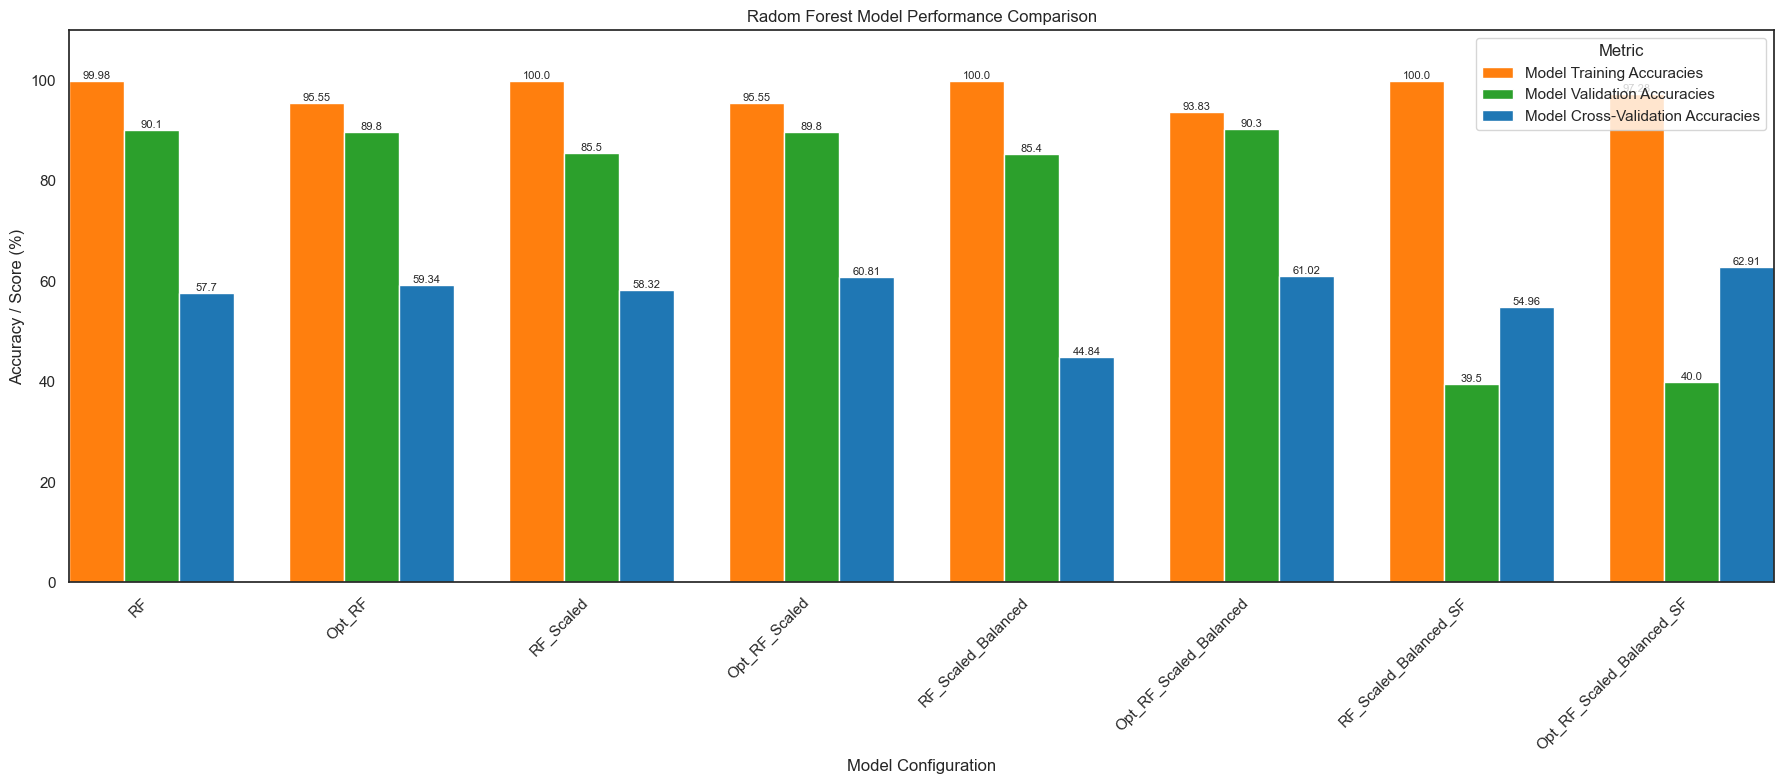

In [77]:
# Assuming 'library', 'Accuracies', 'Validations', 'Cross_Validations' 
# and the rounding function 'r' are defined as in your code.
# Using example data based on your code structure:
library = ['RF',  'Opt_RF', 'RF_Scaled', 'Opt_RF_Scaled', 'RF_Scaled_Balanced', 'Opt_RF_Scaled_Balanced', 'RF_Scaled_Balanced_SF', 'Opt_RF_Scaled_Balanced_SF']
unique_colors = [color_pal[i] for i in range(3)]
def r(x): return round(x * 100, 2) # Example rounding function

# Number of Enthusiasts for different regions
Accuracies = [r(rf_accuracy), r(best_rf_accuracy), r(sf_rf_accuracy), r(sf_best_rf_accuracy), 
              r(scaled_sf_rf_accuracy), r(best_rf_sf_accuracy), r(rf_bal_accuracy), r(best_rf_bal_accuracy)]
Validations = [r(rf_validation), r(best_rf_validation), r(sf_rf_validation), r(sf_best_rf_validation), 
               r(scaled_sf_rf_validation), r(best_rf_sf_validation), r(rf_bal_validation), r(best_rf_bal_validation)]
Cross_Validations = [r(rf_average_r2), r(best_rf_average_r2), r(sf_rf_average_r2), r(sf_opt_best_rf_average_r2),
                     r(scaled_sf_rf_average_r2), r(opt_scaled_sf_rf_average_r2), r(scaled_bal_sf_rf_average_r2), r(opt_scaled_bal_sf_rf_average_r2)]



# --- Start of Corrected Code ---

# Define bar width and positions for 3 bars to be grouped together
bar_width = 0.25
x = np.arange(len(library))
pos1 = x - bar_width
pos2 = x
pos3 = x + bar_width

# Create the plot with a suitable size
plt.figure(figsize=(18, 8))

# 1. Correctly plot the bars
# The plt.bar() function returns a container with all the bars, 
# which we can use later to add the value labels.
bar1 = plt.bar(pos1, Accuracies, width=bar_width, label='Model Training Accuracies', color=unique_colors[1])
bar2 = plt.bar(pos2, Validations, width=bar_width, label='Model Validation Accuracies', color=unique_colors[2])
bar3 = plt.bar(pos3, Cross_Validations, width=bar_width, label='Model Cross-Validation Accuracies', color=unique_colors[0])

# 2. Add value labels on top of the bars
def add_labels(bars):
    """A helper function to add labels to each bar."""
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}', ha='center', va='bottom', fontsize=8)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# 3. Add labels, title, and ticks
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy / Score (%)')
plt.title('Radom Forest Model Performance Comparison')
plt.xticks(x, library, rotation=45, ha="right") # Rotate labels for better readability
plt.legend(title='Metric')
plt.ylim(0, max(max(Accuracies), max(Validations), max(Cross_Validations)) * 1.1) # Adjust y-limit for space
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.margins(x=0)
plt.show()

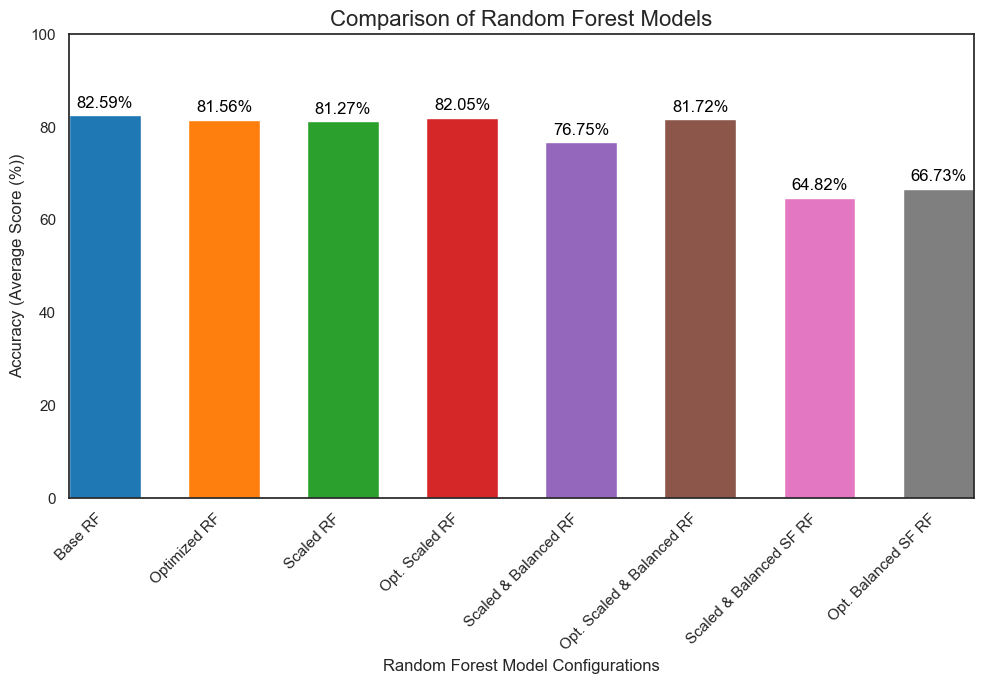

In [79]:
# This cell fixes the syntax error and generates a comparison plot.

# Define model names and their corresponding accuracies
models = ['Base RF', 'Optimized RF', 'Scaled RF', 'Opt. Scaled RF', 'Scaled & Balanced RF', 'Opt. Scaled & Balanced RF', 'Scaled & Balanced SF RF', 'Opt. Balanced SF RF']
accuracies = [0] * len(models)
for i in range(len(models)):
    average = np.mean([Accuracies[i], Validations[i], Cross_Validations[i]])
    accuracies[i] = average

# Create the bar plot
plt.figure(figsize=(10, 7))
bars = plt.bar(models, accuracies, color=[color_pal[i] for i in range(len(models))], width=0.6)

# Add a title and axis labels for clarity
plt.title('Comparison of Random Forest Models', fontsize=16)
plt.xlabel('Random Forest Model Configurations')
plt.ylabel('Accuracy (Average Score (%))', fontsize=12)
plt.xticks(x, models, rotation=45, ha="right") # Rotate labels for better readability
plt.ylim(0, 100)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.margins(x=0)
# Add the accuracy percentage value on top of each bar for easy reading
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=12, color='black')

# Display the final plot
plt.show()

#### Confusion Matrix & Classification Report

Confusion Matrix
A confusion matrix provides a detailed breakdown of a model's performance by showing the number of correct and incorrect predictions for each class. For our lung cancer prediction model:

True Positives (TP): The model correctly predicted patients who have lung cancer.

True Negatives (TN): The model correctly predicted patients who do not have lung cancer.

False Positives (FP): The model incorrectly predicted that a patient has lung cancer when they do not (a "false alarm"). This could lead to unnecessary stress and further testing for the patient.

False Negatives (FN): The model incorrectly predicted that a patient does not have lung cancer when they actually do. This is the most critical error in a medical diagnosis, as it could delay necessary treatment.

The Classification Report uses these values to calculate:

Precision: Of all the patients the model flagged as having cancer, what percentage actually had it? (TP / (TP + FP))

Recall (Sensitivity): Of all the patients who truly had cancer, what percentage did the model correctly identify? (TP / (TP + FN)). High recall is extremely important here to minimize missed diagnoses.

F1-Score: The harmonic mean of Precision and Recall, providing a single score that balances both concerns.

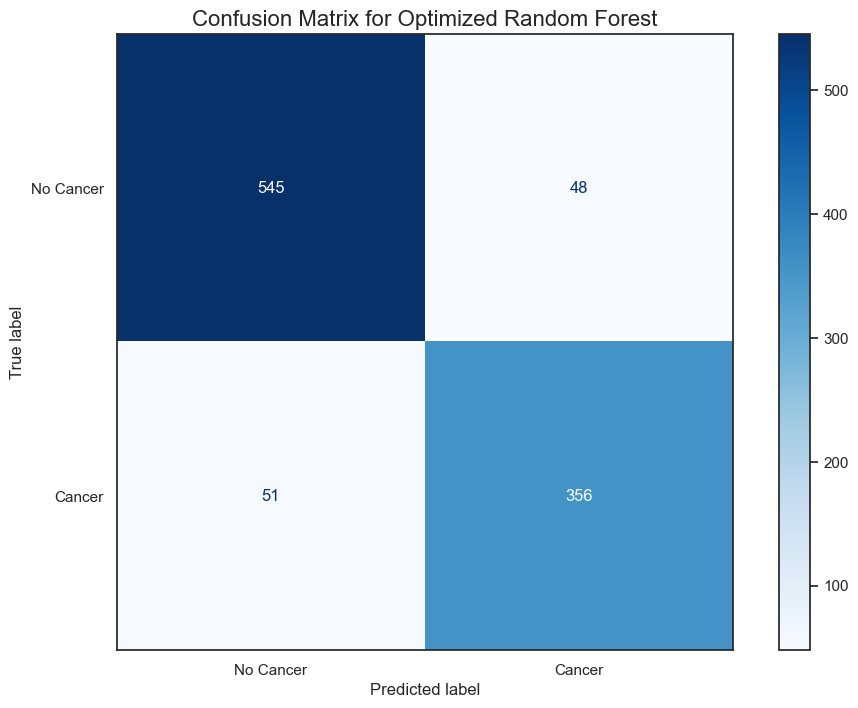


Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.92      0.92       593
   Cancer (1)       0.88      0.87      0.88       407

     accuracy                           0.90      1000
    macro avg       0.90      0.90      0.90      1000
 weighted avg       0.90      0.90      0.90      1000



In [ ]:
# Now, let's evaluate the best performing model based on the previous barchart (Base RF) in more detail.
print("Detailed evaluation of the Optimized Random Forest Model:")

# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred)

# Create a figure and axes with the desired size
fig, ax = plt.subplots(figsize=(12, 8))

# Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Cancer', 'Cancer'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix for Optimized Random Forest', fontsize=16)
plt.show()

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred, target_names=['No Cancer (0)', 'Cancer (1)']))

#### AUC-ROC Curve

AUC-ROC Curve
The Receiver Operating Characteristic (ROC) curve is a graph that shows how well a classification model can distinguish between two classes (in our case, 'Cancer' vs. 'No Cancer') at various classification thresholds.

The Y-axis represents the True Positive Rate (Recall).

The X-axis represents the False Positive Rate.

The Area Under the Curve (AUC) value summarizes the entire ROC curve into a single number:

AUC = 1: The model is a perfect classifier.

AUC = 0.5: The model performs no better than a random guess (represented by the dashed diagonal line).

AUC < 0.5: The model is worse than a random guess.

A higher AUC value (closer to 1.0) indicates that the model is better at correctly identifying patients with lung cancer while minimizing false alarms.

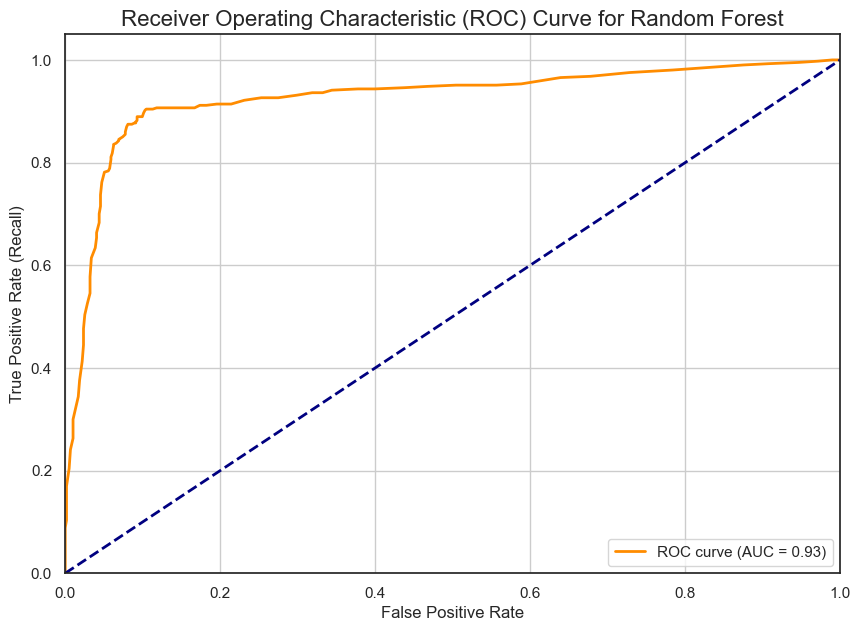

In [91]:
# To plot the AUC-ROC curve, we need the model's prediction probabilities
# We get the probabilities for the positive class ('Cancer')
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Calculate the values for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
# Calculate the Area Under the Curve (AUC)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
# Plot the baseline (random guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Saving the Trained Random Forest Model in a Pickle File

In [92]:
import joblib

# Save the best performing Random Forest model to a file
# This allows us to load and use it later without retraining, e.g., in a web app.
model_filename = 'random_forest_model.joblib'
joblib.dump(rf, model_filename)

print(f"Optimized Random Forest model saved to '{model_filename}'")

Optimized Random Forest model saved to 'random_forest_model.joblib'


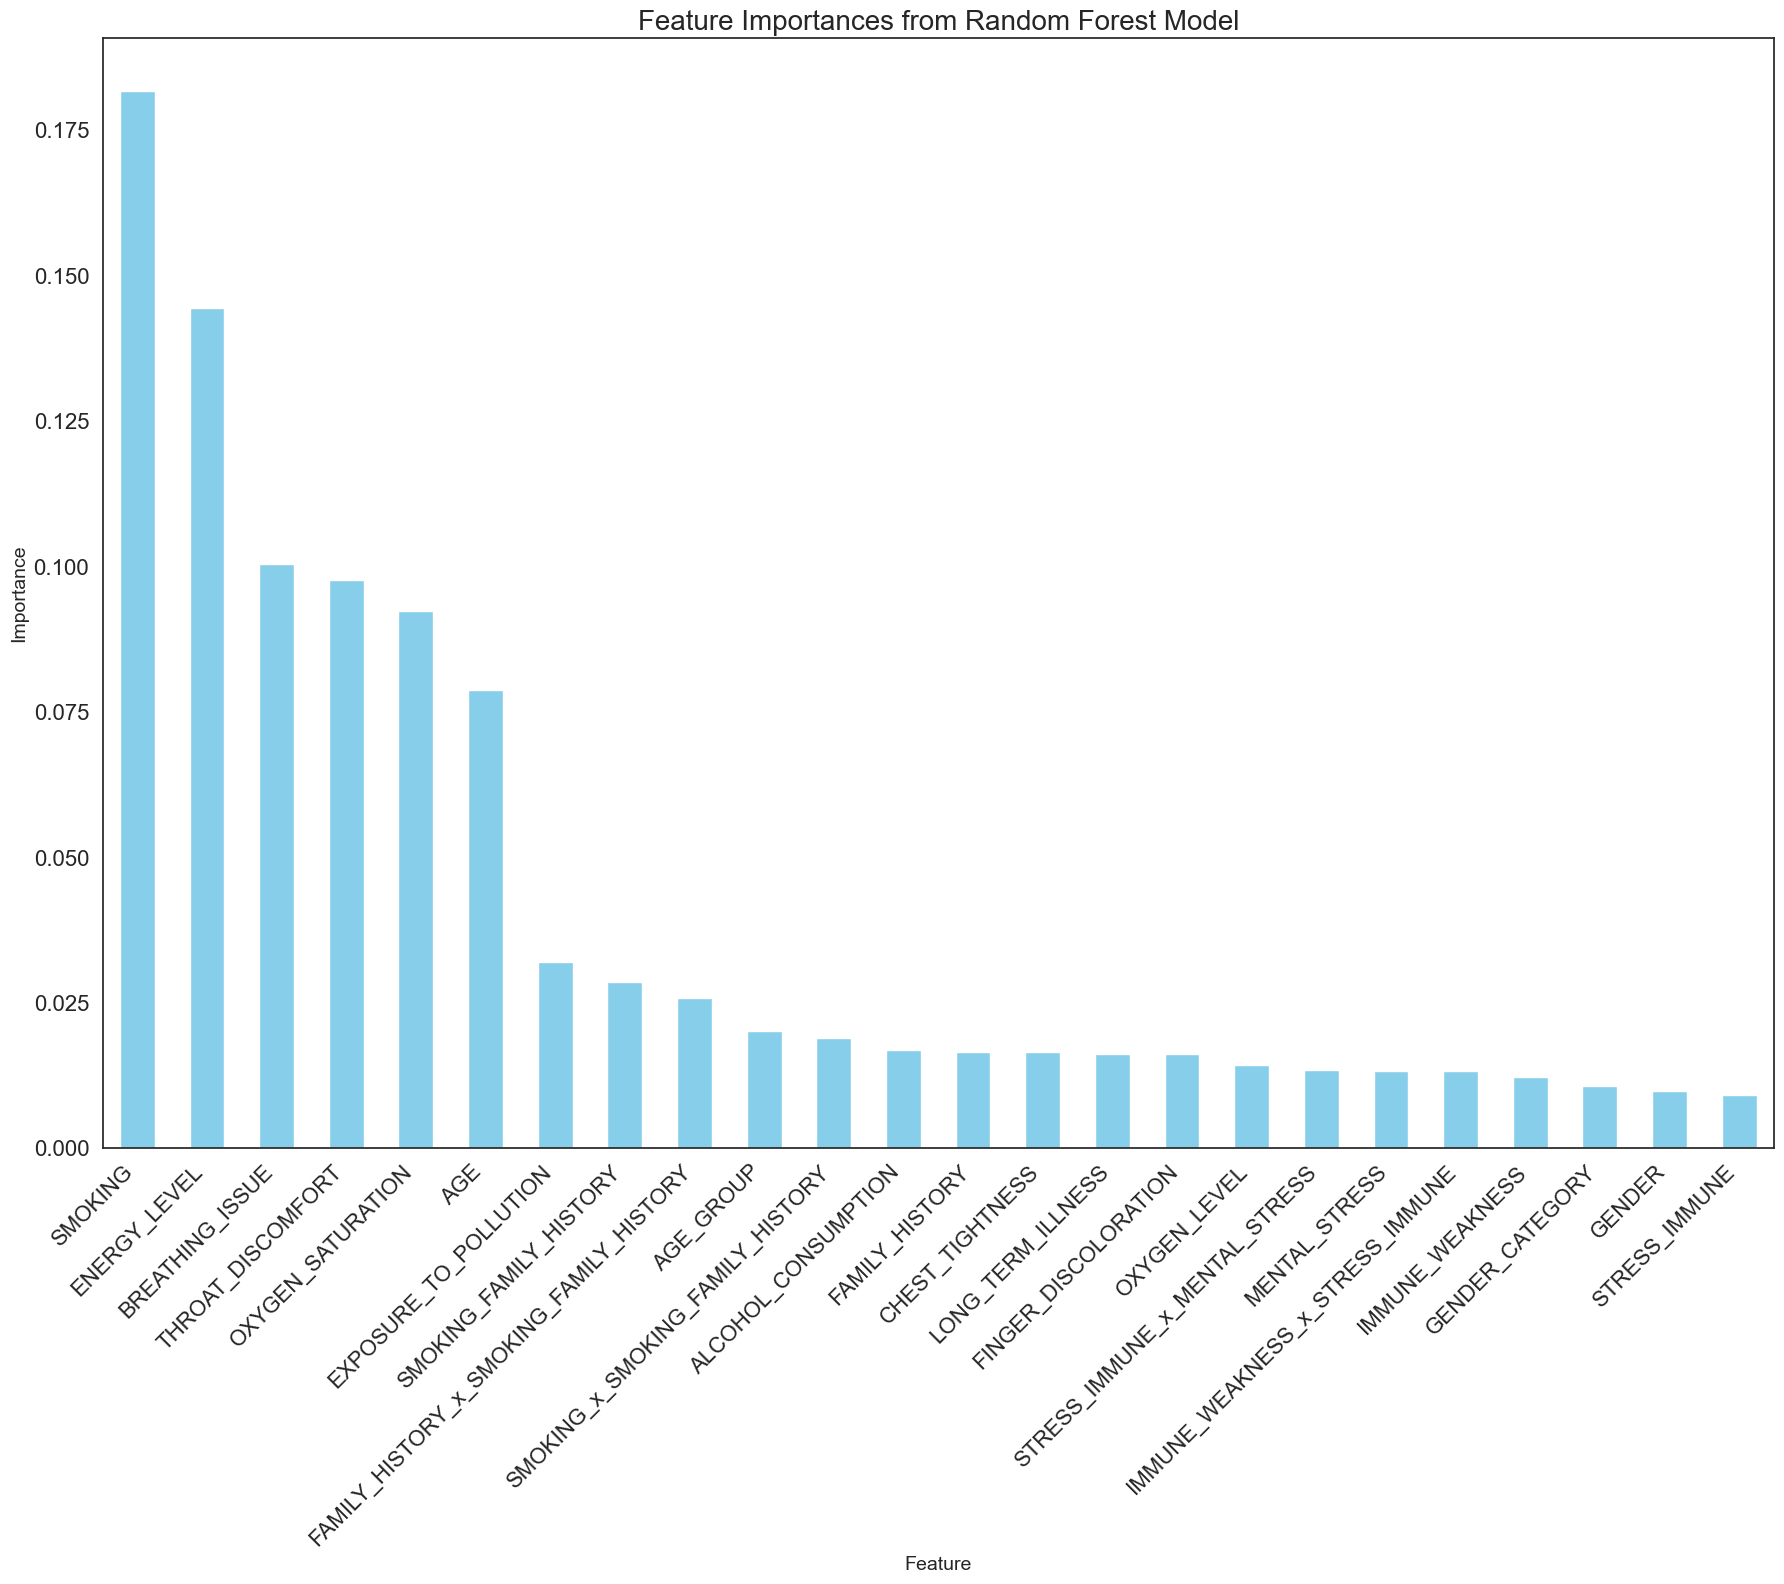

In [94]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Create a figure and axes with the desired size
fig, ax = plt.subplots(figsize=(18, 16))

# Plot a simple bar chart
feature_importances.plot.bar(ax=ax, color='skyblue', fontsize=16)

# Add a title and labels for clarity
ax.set_title('Feature Importances from Random Forest Model', fontsize=20)
ax.set_xlabel('Feature', fontsize=14)
ax.set_ylabel('Importance', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### KNN Classifier

A Brief Explanation of K-Nearest Neighbors (KNN)
The K-Nearest Neighbors (KNN) algorithm is a simple, yet effective, non-parametric classification method. Unlike other models that learn a "function" from the training data, KNN stores the entire dataset.

Here's how it makes a prediction for a new data point:

Find the Neighbors: It calculates the distance (e.g., Euclidean distance) from the new data point to all the data points in the training set.

Identify the 'K' Closest: It identifies the 'K' closest data points, where 'K' is a number you choose (this is the key hyperparameter we tuned).

Vote for the Class: It looks at the class labels of these 'K' neighbors and assigns the new data point the class that is most common among them (majority vote).

Because it relies on distance, feature scaling (which we performed during preprocessing) is crucial for KNN. Without scaling, features with larger ranges would unfairly dominate the distance calculation and skew the results.

#### Train KNN Base Model Training on All Features

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the base KNN model with default parameters (n_neighbors=5)
base_knn = KNeighborsClassifier()
base_knn.fit(X_train, y_train)

# Make predictions on the test set
y_test_pred_base_knn = base_knn.predict(X_test)
y_train_pred_base_knn = base_knn.predict(X_train)

# Evaluate the model's accuracy
validation_base_knn = accuracy_score(y_test, y_test_pred_base_knn)
training_base_knn = accuracy_score(y_train, y_train_pred_base_knn)
print(f"Base KNN Training Accuracy: {training_base_knn:.1%}")
print(f"Base KNN Validation Accuracy: {validation_base_knn:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_base_knn, target_names=['No Cancer (0)', 'Cancer (1)']))

Base KNN Training Accuracy: 80.3%
Base KNN Validation Accuracy: 67.1%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.71      0.76      0.73       593
   Cancer (1)       0.61      0.55      0.58       407

     accuracy                           0.67      1000
    macro avg       0.66      0.65      0.65      1000
 weighted avg       0.67      0.67      0.67      1000



#### Train KNN Hyperparameter Tuning on All Features

In [108]:
# Define the parameter grid for GridSearchCV
# We will tune the number of neighbors, the weighting scheme, and the distance metric.
from sklearn.model_selection import GridSearchCV, StratifiedKFold


param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Use the same stratified k-fold cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5)

# Initialize GridSearchCV to find the best hyperparameters
grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(),
                               param_grid=param_grid_knn,
                               cv=cv_strat,
                               n_jobs=-1,
                               verbose=0,
                               scoring='accuracy')

# Fit the grid search to the training data
grid_search_knn.fit(X_train, y_train)

# Get the best estimator from the grid search
best_knn = grid_search_knn.best_estimator_
print("Best parameters found for KNN: ", grid_search_knn.best_params_)

# Make predictions with the optimized model
y_test_pred_best_knn = best_knn.predict(X_test)
y_train_pred_best_knn = best_knn.predict(X_train)

# Evaluate the optimized model
validation_best_knn = accuracy_score(y_test, y_test_pred_best_knn)
training_best_knn = accuracy_score(y_train, y_train_pred_best_knn)
print(f"Optimized KNN Training Accuracy: {training_best_knn:.1%}")
print(f"Optimized KNN Validation Accuracy: {validation_best_knn:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_best_knn, target_names=['No Cancer (0)', 'Cancer (1)']))

Best parameters found for KNN:  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Optimized KNN Training Accuracy: 100.0%
Optimized KNN Validation Accuracy: 74.1%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.77      0.81      0.79       593
   Cancer (1)       0.70      0.64      0.67       407

     accuracy                           0.74      1000
    macro avg       0.73      0.73      0.73      1000
 weighted avg       0.74      0.74      0.74      1000



#### Train KNN with Selected Features

In [130]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the base KNN model with default parameters (n_neighbors=5)
base_knn_sf = KNeighborsClassifier()
base_knn_sf.fit(X_train[selected_bal_df_ranked_features], y_train)

# Make predictions on the test set
y_test_pred_base_knn_sf = base_knn_sf.predict(X_test[selected_bal_df_ranked_features])
y_train_pred_base_knn_sf = base_knn_sf.predict(X_train[selected_bal_df_ranked_features])

# Evaluate the model's accuracy
validation_base_knn_sf = accuracy_score(y_test, y_test_pred_base_knn_sf)
training_base_knn_sf = accuracy_score(y_train, y_train_pred_base_knn_sf)
print(f"Base KNN Training Accuracy: {training_base_knn_sf:.1%}")
print(f"Base KNN Validation Accuracy: {validation_base_knn_sf:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_base_knn_sf, target_names=['No Cancer (0)', 'Cancer (1)']))

Base KNN Training Accuracy: 89.6%
Base KNN Validation Accuracy: 85.2%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.83      0.87       593
   Cancer (1)       0.78      0.88      0.83       407

     accuracy                           0.85      1000
    macro avg       0.85      0.86      0.85      1000
 weighted avg       0.86      0.85      0.85      1000



#### Perform Parameter Optimization on KNN Classifier with Selected Features in Dataset

In [132]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Use the same stratified k-fold cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5)

# Initialize GridSearchCV to find the best hyperparameters
grid_search_knn_sf = GridSearchCV(estimator=KNeighborsClassifier(),
                               param_grid=param_grid_knn,
                               cv=cv_strat,
                               n_jobs=-1,
                               verbose=0,
                               scoring='accuracy')

# Fit the grid search to the training data
grid_search_knn_sf.fit(X_train[selected_bal_df_ranked_features], y_train)

# Get the best estimator from the grid search
best_knn_sf = grid_search_knn_sf.best_estimator_
print("Best parameters found for KNN: ", grid_search_knn_sf.best_params_)

# Make predictions with the optimized model
y_test_pred_best_knn_sf = best_knn_sf.predict(X_test[selected_bal_df_ranked_features])
y_train_pred_best_knn_sf = best_knn_sf.predict(X_train[selected_bal_df_ranked_features])

# Evaluate the optimized model
validation_best_knn_sf = accuracy_score(y_test, y_test_pred_best_knn_sf)
training_best_knn_sf = accuracy_score(y_train, y_train_pred_best_knn_sf)
print(f"Optimized KNN Training Accuracy: {training_best_knn_sf:.1%}")
print(f"Optimized KNN Validation Accuracy: {validation_best_knn_sf:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_best_knn_sf, target_names=['No Cancer (0)', 'Cancer (1)']))

Best parameters found for KNN:  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Optimized KNN Training Accuracy: 100.0%
Optimized KNN Validation Accuracy: 85.8%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.85      0.88       593
   Cancer (1)       0.80      0.87      0.83       407

     accuracy                           0.86      1000
    macro avg       0.85      0.86      0.85      1000
 weighted avg       0.86      0.86      0.86      1000



#### Train KNN with Scaled Selected Features

In [109]:
# Initialize and train the base KNN model with default parameters (n_neighbors=5)
base_knn_sr = KNeighborsClassifier()
base_knn_sr.fit(X_df_train_scaled[selected_bal_df_ranked_features], y_train)

# Make predictions on the test set
y_test_pred_base_knn_sr = base_knn_sr.predict(X_df_test_scaled[selected_bal_df_ranked_features])
y_train_pred_base_knn_sr = base_knn_sr.predict(X_df_train_scaled[selected_bal_df_ranked_features])

# Evaluate the model's accuracy
validation_base_knn_sr = accuracy_score(y_test, y_test_pred_base_knn_sr)
training_base_knn_sr = accuracy_score(y_train, y_train_pred_base_knn_sr)
print(f"Base KNN Training Accuracy: {training_base_knn_sr:.1%}")
print(f"Base KNN Validation Accuracy: {validation_base_knn_sr:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_base_knn_sr, target_names=['No Cancer (0)', 'Cancer (1)']))

Base KNN Training Accuracy: 92.1%
Base KNN Validation Accuracy: 89.8%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.92      0.91       593
   Cancer (1)       0.88      0.87      0.87       407

     accuracy                           0.90      1000
    macro avg       0.90      0.89      0.89      1000
 weighted avg       0.90      0.90      0.90      1000



#### Perform Parameter Optimization on KNN Classifier with Scaled Selected Features in Dataset

In [111]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Use the same stratified k-fold cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5)

# Initialize GridSearchCV to find the best hyperparameters
grid_search_knn_sr = GridSearchCV(estimator=KNeighborsClassifier(),
                               param_grid=param_grid_knn,
                               cv=cv_strat,
                               n_jobs=-1,
                               verbose=0,
                               scoring='accuracy')

# Fit the grid search to the training data
grid_search_knn_sr.fit(X_df_train_scaled[selected_bal_df_ranked_features], y_train)

# Get the best estimator from the grid search
best_knn_opt_sr = grid_search_knn_sr.best_estimator_
print("Best parameters found for KNN: ", grid_search_knn_sr.best_params_)

# Make predictions with the optimized model
y_test_pred_best_knn_sr = best_knn_opt_sr.predict(X_df_test_scaled[selected_bal_df_ranked_features])
y_train_pred_best_knn_sr = best_knn_opt_sr.predict(X_df_train_scaled[selected_bal_df_ranked_features])

# Evaluate the optimized model
validation_best_knn_sr = accuracy_score(y_test, y_test_pred_best_knn_sr)
training_best_knn_sr = accuracy_score(y_train, y_train_pred_best_knn_sr)
print(f"Optimized KNN Training Accuracy: {training_best_knn_sr:.1%}")
print(f"Optimized KNN Validation Accuracy: {validation_best_knn_sr:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized KNN:\n")
print(classification_report(y_test, y_test_pred_best_knn_sr, target_names=['No Cancer (0)', 'Cancer (1)']))

Best parameters found for KNN:  {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Optimized KNN Training Accuracy: 92.1%
Optimized KNN Validation Accuracy: 89.8%

Classification Report for Optimized KNN:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.92      0.91       593
   Cancer (1)       0.88      0.87      0.87       407

     accuracy                           0.90      1000
    macro avg       0.90      0.89      0.89      1000
 weighted avg       0.90      0.90      0.90      1000



#### Train KNN with Scaled Balanced on Selected Features

In [123]:
# Initialize and train the base KNN model with default parameters (n_neighbors=5)
scaled_knn_bal_sr = KNeighborsClassifier()
scaled_knn_bal_sr.fit(X_train_bal_df[selected_bal_df_ranked_features], y_train_bal)

# Make predictions on the test set
y_test_pred_scaled_knn_bal_sr = scaled_knn_bal_sr.predict(X_test_bal_df[selected_bal_df_ranked_features])
y_train_pred_scaled_knn_bal_sr = scaled_knn_bal_sr.predict(X_train_bal_df[selected_bal_df_ranked_features])

# Evaluate the model's accuracy
validation_scale_knn_bal_sr = accuracy_score(y_test_bal, y_test_pred_scaled_knn_bal_sr)
training_scale_knn_bal_sr = accuracy_score(y_train_bal, y_train_pred_scaled_knn_bal_sr)
print(f"Base KNN Training Accuracy: {training_scale_knn_bal_sr:.1%}")
print(f"Base KNN Validation Accuracy: {validation_scale_knn_bal_sr:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test_bal, y_test_pred_scaled_knn_bal_sr, target_names=['No Cancer (0)', 'Cancer (1)']))

Base KNN Training Accuracy: 92.4%
Base KNN Validation Accuracy: 89.5%

Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.89      0.91      0.90       593
   Cancer (1)       0.91      0.88      0.89       593

     accuracy                           0.90      1186
    macro avg       0.90      0.90      0.90      1186
 weighted avg       0.90      0.90      0.90      1186



#### Perform Parameter Optimization on KNN Classifier with Scaled Balanced Dataset on Selected Features

In [127]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Use the same stratified k-fold cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5)

# Initialize GridSearchCV to find the best hyperparameters
grid_search_knn_sf_sr = GridSearchCV(estimator=KNeighborsClassifier(),
                               param_grid=param_grid_knn,
                               cv=cv_strat,
                               n_jobs=-1,
                               verbose=0,
                               scoring='accuracy')

# Fit the grid search to the training data
grid_search_knn_sf_sr.fit(X_train_bal_df[selected_bal_df_ranked_features], y_train_bal)

# Get the best estimator from the grid search
best_knn_opt_sf_sr = grid_search_knn_sf_sr.best_estimator_
print("Best parameters found for KNN: ", grid_search_knn_sf_sr.best_params_)

# Make predictions with the optimized model
y_test_pred_best_knn_sf_sr = best_knn_opt_sf_sr.predict(X_test_bal_df[selected_bal_df_ranked_features])
y_train_pred_best_knn_sf_sr = best_knn_opt_sf_sr.predict(X_train_bal_df[selected_bal_df_ranked_features])

# Evaluate the optimized model
validation_best_knn_sf_sr = accuracy_score(y_test_bal, y_test_pred_best_knn_sf_sr)
training_best_knn_sf_sr = accuracy_score(y_train_bal, y_train_pred_best_knn_sf_sr)
print(f"Optimized KNN Training Accuracy: {training_best_knn_sf_sr:.1%}")
print(f"Optimized KNN Validation Accuracy: {validation_best_knn_sf_sr:.1%}")

# Display a detailed classification report
print("\nClassification Report for Optimized KNN:\n")
print(classification_report(y_test_bal, y_test_pred_best_knn_sf_sr, target_names=['No Cancer (0)', 'Cancer (1)']))

Best parameters found for KNN:  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Optimized KNN Training Accuracy: 92.4%
Optimized KNN Validation Accuracy: 89.6%

Classification Report for Optimized KNN:

               precision    recall  f1-score   support

No Cancer (0)       0.89      0.91      0.90       593
   Cancer (1)       0.91      0.88      0.89       593

     accuracy                           0.90      1186
    macro avg       0.90      0.90      0.90      1186
 weighted avg       0.90      0.90      0.90      1186



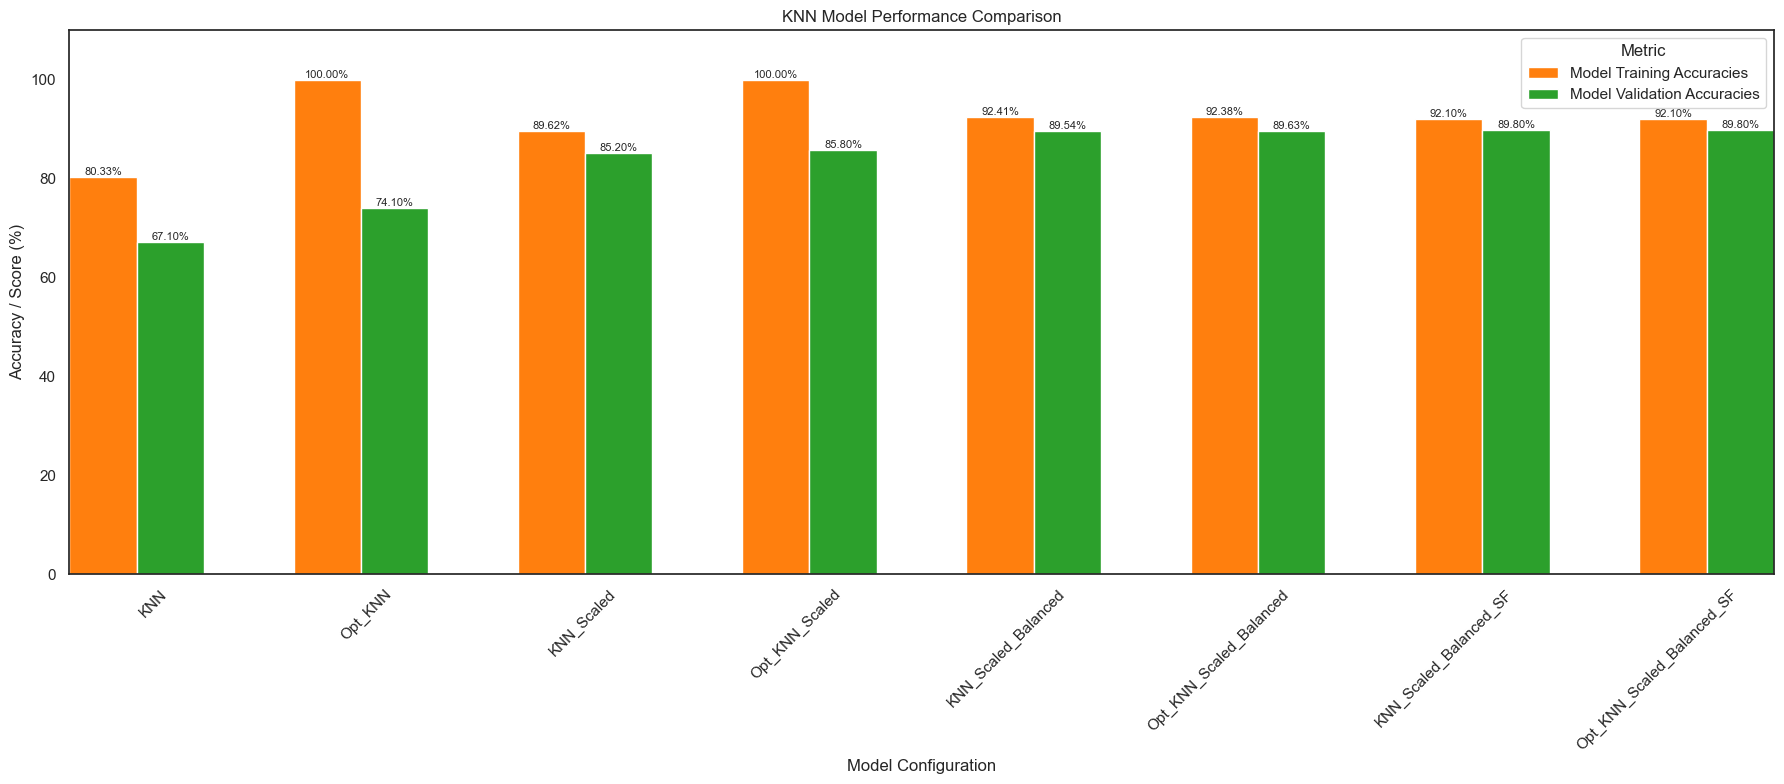

In [135]:
# Assuming 'library', 'Accuracies', 'Validations', 'Cross_Validations' 
# and the rounding function 'r' are defined as in your code.
# Using example data based on your code structure:
knn_library = ['KNN',  'Opt_KNN', 'KNN_Scaled', 'Opt_KNN_Scaled', 'KNN_Scaled_Balanced', 'Opt_KNN_Scaled_Balanced', 'KNN_Scaled_Balanced_SF', 'Opt_KNN_Scaled_Balanced_SF']
knn_unique_colors = [color_pal[i] for i in range(3)]
# def r(x): return round(x * 100, 2) # Example rounding function

# Number of Enthusiasts for different regions
KNN_Accuracies = [r(training_base_knn), r(training_best_knn), r(training_base_knn_sf), r(training_best_knn_sf), 
              r(training_scale_knn_bal_sr), r(training_best_knn_sf_sr), r(training_base_knn_sr), r(training_best_knn_sr)]
KNN_Validations = [r(validation_base_knn), r(validation_best_knn), r(validation_base_knn_sf), r(validation_best_knn_sf), 
               r(validation_scale_knn_bal_sr), r(validation_best_knn_sf_sr), r(validation_base_knn_sr), r(validation_best_knn_sr)]


# --- Start of Corrected Code ---

# Define bar width and positions for 3 bars to be grouped together
bar_width = 0.3
x = np.arange(len(knn_library))
pos1 = x - bar_width
pos2 = x

# Create the plot with a suitable size
plt.figure(figsize=(18, 8))

# 1. Correctly plot the bars
# The plt.bar() function returns a container with all the bars, 
# which we can use later to add the value labels.
bar1 = plt.bar(pos1, KNN_Accuracies, width=bar_width, label='Model Training Accuracies', color=knn_unique_colors[1])
bar2 = plt.bar(pos2, KNN_Validations, width=bar_width, label='Model Validation Accuracies', color=knn_unique_colors[2])

# 2. Add value labels on top of the bars
def add_labels(bars):
    """A helper function to add labels to each bar."""
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=8)

add_labels(bar1)
add_labels(bar2)

# 3. Add labels, title, and ticks
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy / Score (%)')
plt.title('KNN Model Performance Comparison')
plt.xticks(x, knn_library, rotation=45, ha="right") # Rotate labels for better readability
plt.legend(title='Metric')
plt.ylim(0, max(max(KNN_Accuracies), max(KNN_Validations)) * 1.1) # Adjust y-limit for space
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.margins(x=0)
plt.show()

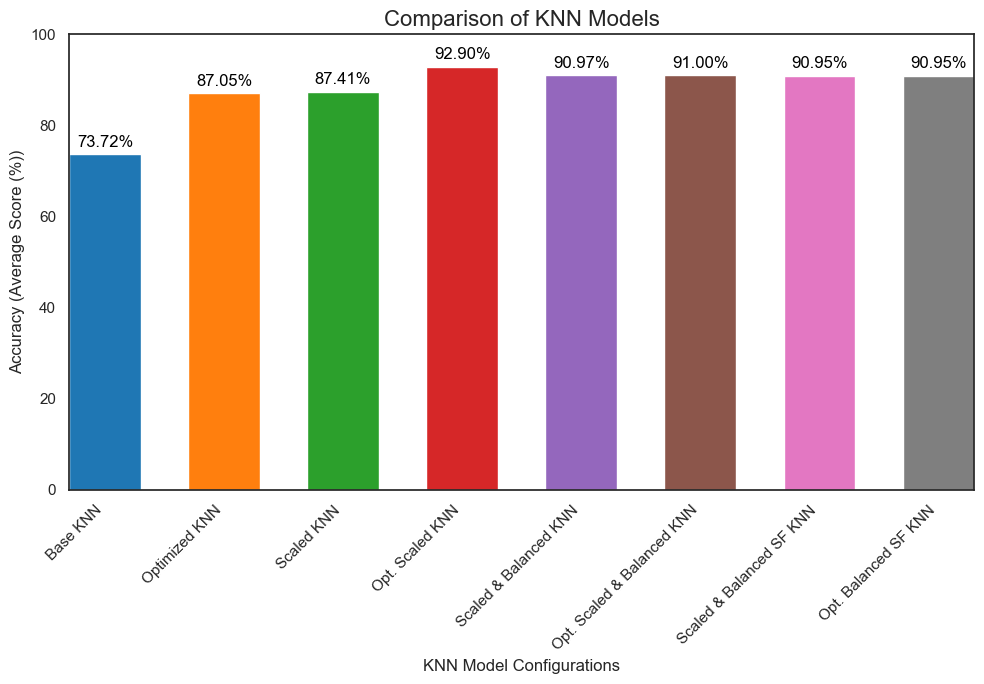

In [134]:
# This cell fixes the syntax error and generates a comparison plot.

# Define model names and their corresponding accuracies
knn_models = ['Base KNN', 'Optimized KNN', 'Scaled KNN', 'Opt. Scaled KNN', 'Scaled & Balanced KNN', 'Opt. Scaled & Balanced KNN', 'Scaled & Balanced SF KNN', 'Opt. Balanced SF KNN']
knn_accuracies = [0] * len(knn_models)
for i in range(len(knn_models)):
    average = np.mean([KNN_Accuracies[i], KNN_Validations[i]])
    knn_accuracies[i] = average

# Create the bar plot
plt.figure(figsize=(10, 7))
bars = plt.bar(knn_models, knn_accuracies, color=[color_pal[i] for i in range(len(knn_models))], width=0.6)

# Add a title and axis labels for clarity
plt.title('Comparison of KNN Models', fontsize=16)
plt.xlabel('KNN Model Configurations')
plt.ylabel('Accuracy (Average Score (%))', fontsize=12)
plt.xticks(x, knn_models, rotation=45, ha="right") # Rotate labels for better readability
plt.ylim(0, 100)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.margins(x=0)
# Add the accuracy percentage value on top of each bar for easy reading
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=12, color='black')

# Display the final plot
plt.show()

Detailed evaluation of the Optimized KNN Model:


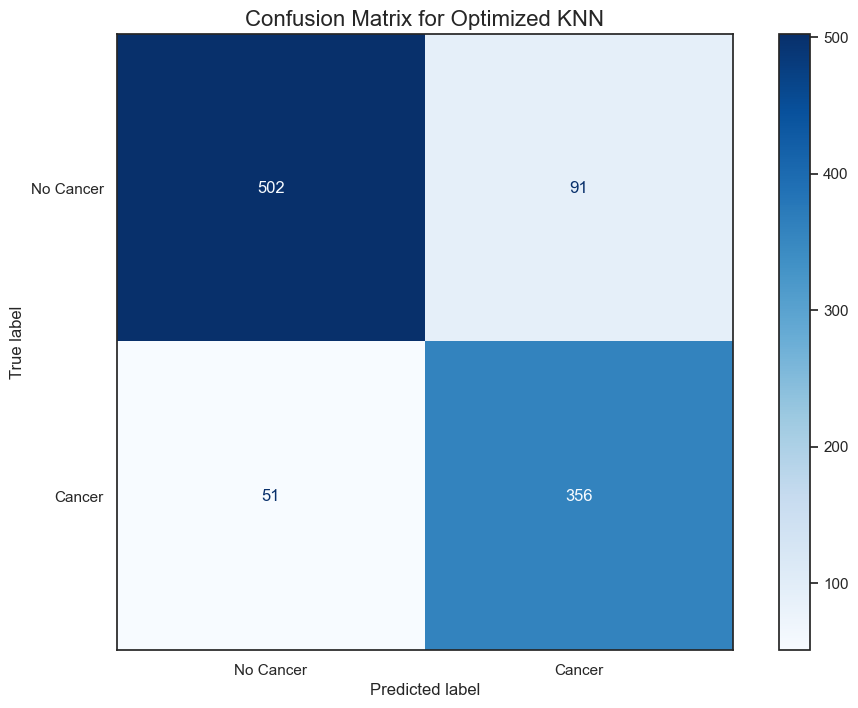


Classification Report for Optimized Random Forest:

               precision    recall  f1-score   support

No Cancer (0)       0.91      0.85      0.88       593
   Cancer (1)       0.80      0.87      0.83       407

     accuracy                           0.86      1000
    macro avg       0.85      0.86      0.85      1000
 weighted avg       0.86      0.86      0.86      1000



In [136]:
# Now, let's evaluate the best performing model based on the previous barchart (Base RF) in more detail.
print("Detailed evaluation of the Optimized KNN Model:")

# Generate the confusion matrix
cm_knn = confusion_matrix(y_test, y_test_pred_best_knn_sf)

# Create a figure and axes with the desired size
fig, ax = plt.subplots(figsize=(12, 8))

# Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Cancer', 'Cancer'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix for Optimized KNN', fontsize=16)
plt.show()

# Display a detailed classification report
print("\nClassification Report for Optimized Random Forest:\n")
print(classification_report(y_test, y_test_pred_best_knn_sf, target_names=['No Cancer (0)', 'Cancer (1)']))

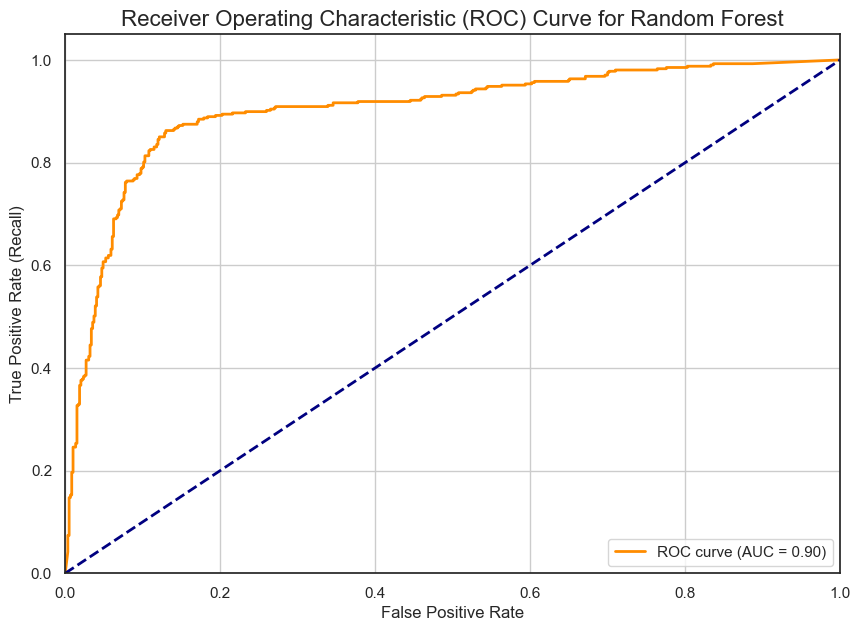

In [138]:
# To plot the AUC-ROC curve, we need the model's prediction probabilities
# We get the probabilities for the positive class ('Cancer')
y_pred_proba_knn = best_knn_sf.predict_proba(X_test[selected_bal_df_ranked_features])[:, 1]

# Calculate the values for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_knn)
# Calculate the Area Under the Curve (AUC)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.2f})')
# Plot the baseline (random guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [139]:
# Save the best performing KNN model to a file
# This allows us to load and use it later without retraining, e.g., in a web app.
model_filename = 'k_nearest_neighbors_model.joblib'
joblib.dump(best_knn_sf, model_filename)

print(f"Optimized KNN model saved to '{model_filename}'")

Optimized KNN model saved to 'k_nearest_neighbors_model.joblib'


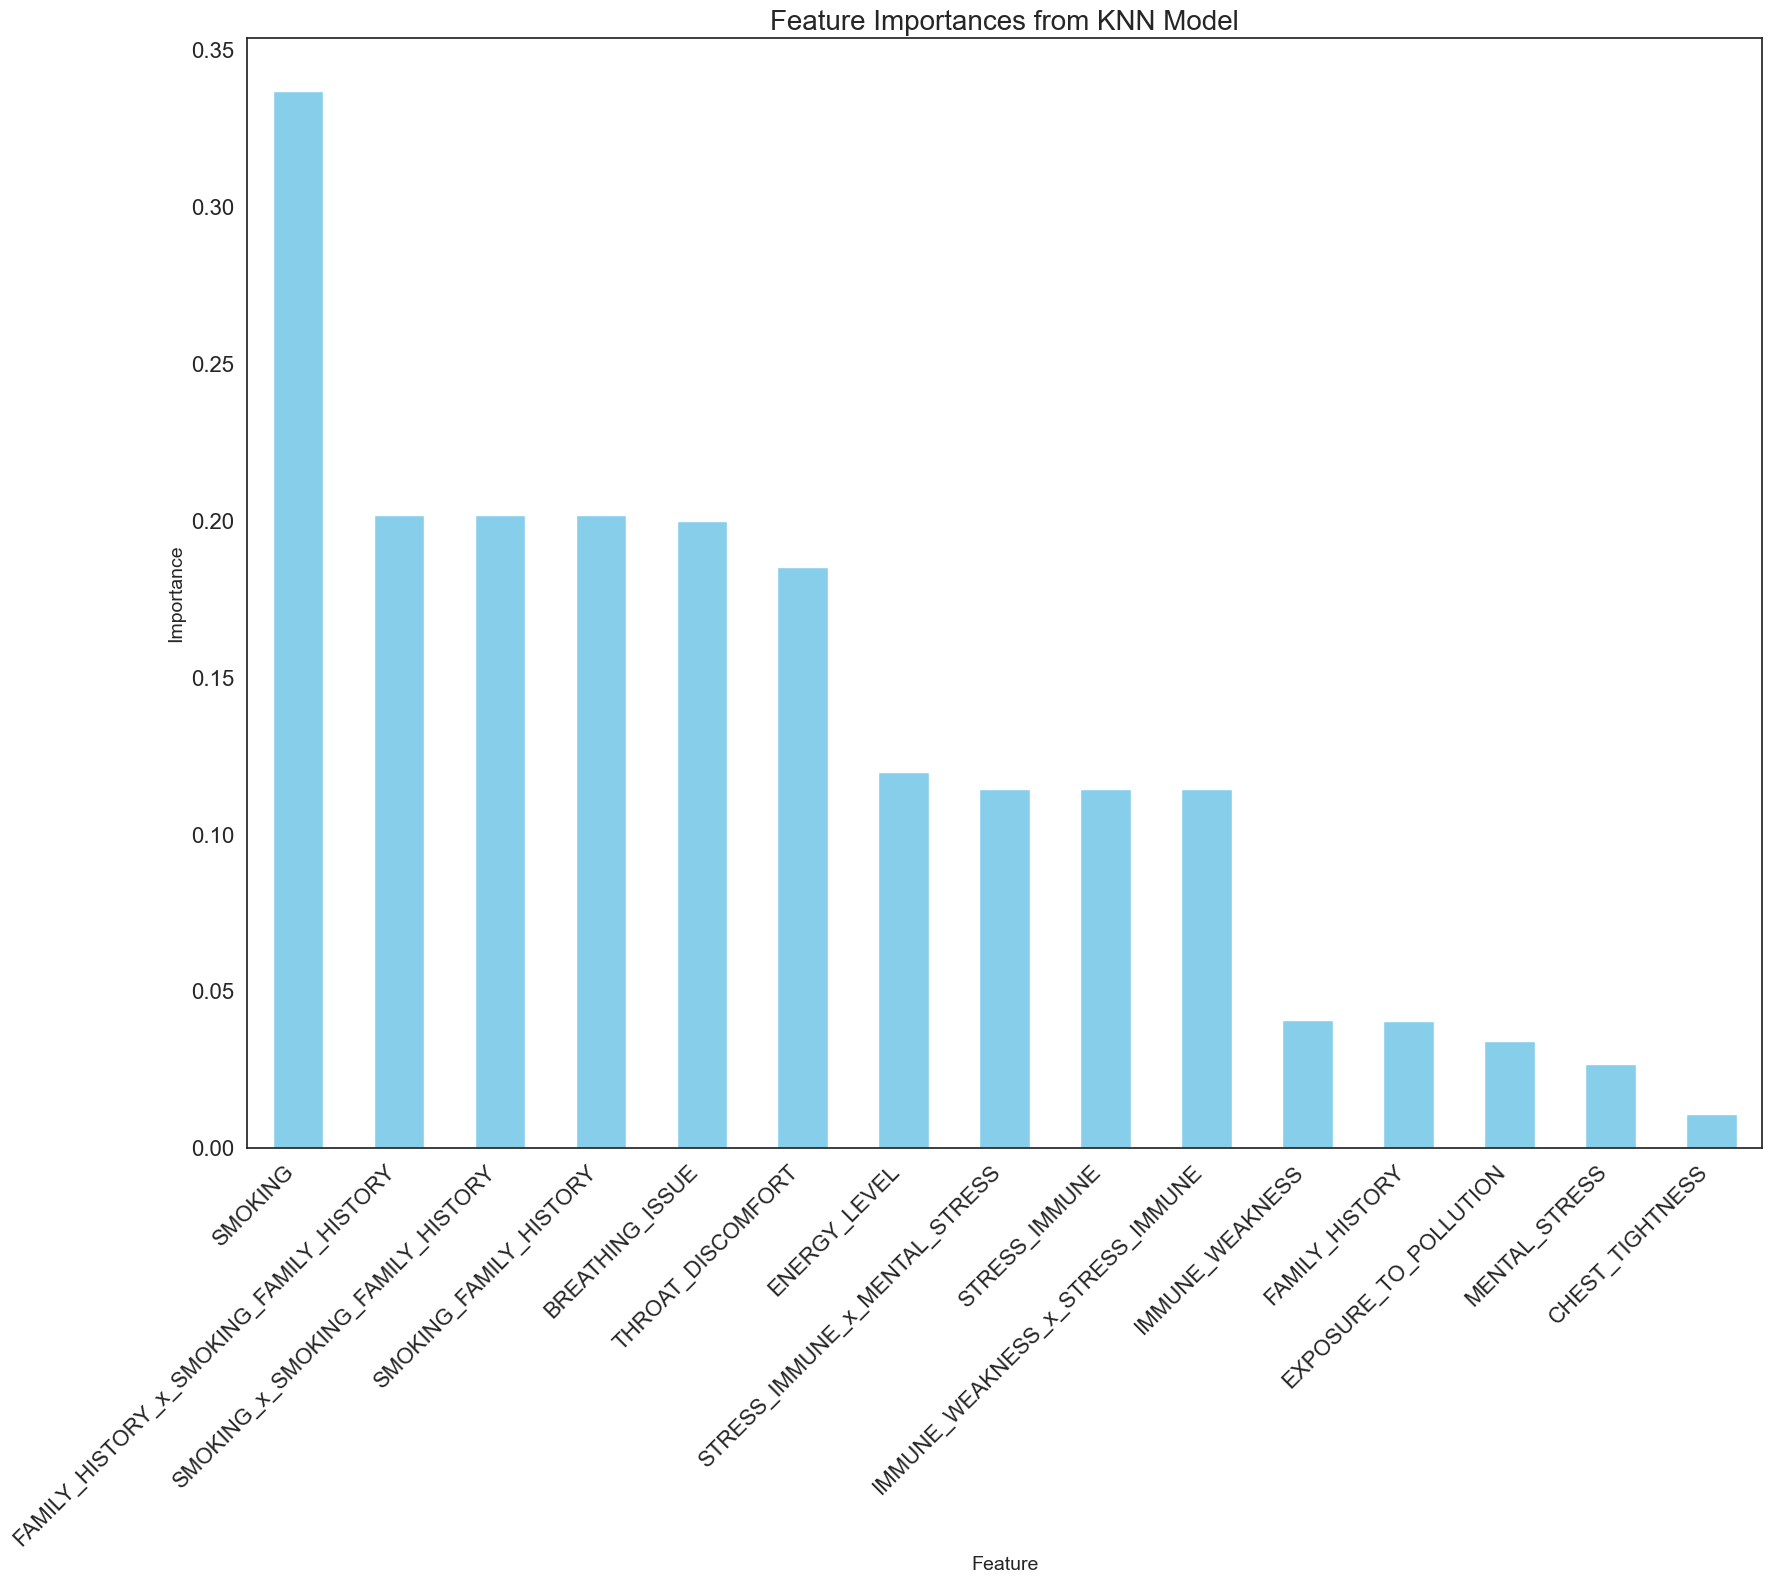

In [148]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(bal_df_ranked_features.loc[0:14, 'Average_Score'].values, index=selected_bal_df_ranked_features).sort_values(ascending=False)

# Create a figure and axes with the desired size
fig, ax = plt.subplots(figsize=(18, 16))

# Plot a simple bar chart
feature_importances.plot.bar(ax=ax, color='skyblue', fontsize=16)

# Add a title and labels for clarity
ax.set_title('Feature Importances from KNN Model', fontsize=20)
ax.set_xlabel('Feature', fontsize=14)
ax.set_ylabel('Importance', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Logistic Regression Classifier

A Brief Explanation of Logistic Regression
Despite its name, Logistic Regression is a statistical model used for binary classification tasks, not regression. It's one of the most fundamental and widely used classification algorithms.

Here's the core idea:

Linear Combination: Just like Linear Regression, it starts by calculating a weighted sum of the input features.

Sigmoid Function: Instead of using that sum as the final output, it passes the result through a special function called the sigmoid (or logistic) function.

Probability Output: The sigmoid function squashes the output to a value between 0 and 1. This value can be interpreted as the probability that the given input belongs to the positive class (in our case, the probability of having lung cancer).

A decision boundary (typically 0.5) is then used to convert this probability into a final class prediction. If the probability is greater than 0.5, the model predicts 'Cancer'; otherwise, it predicts 'No Cancer'. The model learns the optimal weights for the features during the training process to best separate the two classes.

#### Regression Base Model Training

In [ ]:
# Initialize and train the base Logistic Regression model
# We set max_iter to 1000 to ensure the model converges, especially with scaled data.
base_log_reg = LogisticRegression(random_state=42, max_iter=1000)
base_log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_base_log_reg = base_log_reg.predict(X_test)

# Evaluate the model's accuracy
accuracy_base_log_reg = accuracy_score(y_test, y_pred_base_log_reg)
print(f"Base Logistic Regression Accuracy: {accuracy_base_log_reg:.1%}")

#### Logistic Regression Hyperparameter Tuning

In [ ]:
# Define the parameter grid for GridSearchCV
# We'll tune the regularization strength 'C' and the solver.
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Use the same stratified k-fold cross-validation
cv_strat = StratifiedKFold(n_splits=5)

# Initialize GridSearchCV
grid_search_log_reg = GridSearchCV(estimator=LogisticRegression(random_state=42, max_iter=5000),
                                   param_grid=param_grid_log_reg,
                                   cv=cv_strat,
                                   n_jobs=-1,
                                   verbose=0,
                                   scoring='accuracy')

# Fit the grid search to the training data
grid_search_log_reg.fit(X_train, y_train)

# Get the best estimator
best_log_reg = grid_search_log_reg.best_estimator_
print("Best parameters found for Logistic Regression: ", grid_search_log_reg.best_params_)

# Make predictions with the optimized model
y_pred_best_log_reg = best_log_reg.predict(X_test)

# Evaluate the optimized model
accuracy_best_log_reg = accuracy_score(y_test, y_pred_best_log_reg)
print(f"Optimized Logistic Regression Accuracy: {accuracy_best_log_reg:.1%}")


#### Plot Logistic Regression Optimization Results

In [ ]:
# Define model names and their accuracies for plotting
models_log_reg = ['Base Logistic Regression', 'Optimized Logistic Regression']
accuracies_log_reg = [accuracy_base_log_reg, accuracy_best_log_reg]

# Create the bar plot
plt.figure(figsize=(10, 7))
bars_log_reg = plt.bar(models_log_reg, accuracies_log_reg, color=['skyblue', 'lightgreen'], width=0.6)

# Add title and labels
plt.title('Logistic Regression: Base vs. Optimized Model Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.8, 1.0)

# Add accuracy labels on bars
for bar in bars_log_reg:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.1%}', ha='center', va='bottom', fontsize=12, color='black')

# Display the plot
plt.show()

#### Logistic Regression Confusion Matrix & Report

In [ ]:
print("\nDetailed evaluation of the Optimized Logistic Regression Model:")

# Generate the confusion matrix for the best model
cm_log_reg = confusion_matrix(y_test, y_pred_best_log_reg)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.title('Confusion Matrix for Optimized Logistic Regression', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Display the classification report
print("\nClassification Report for Optimized Logistic Regression:\n")
print(classification_report(y_test, y_pred_best_log_reg, target_names=['No Cancer (0)', 'Cancer (1)']))

#### Logistic Regression AUC-ROC Curve

In [ ]:
# Get prediction probabilities for the positive class
y_pred_proba_log_reg = best_log_reg.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Saving the Trained Logistic Regression Model

In [ ]:
# Save the best model to a file
model_filename_log_reg = 'logistic_regression_model.joblib'
joblib.dump(best_log_reg, model_filename_log_reg)

print(f"Optimized Logistic Regression model saved to '{model_filename_log_reg}'")

### Linear Regression Classifier

Linear Regression is a fundamental statistical method primarily used for modeling the relationship 
between a dependent variable and one or more independent variables by fitting a linear equation 
to the observed data. While its core function is to predict continuous outcomes (regression), 
it can be adapted for binary classification tasks.

The adaptation works as follows:
1.  Linear Equation: The model learns a linear equation that best represents the relationship 
    between the input features and the target variable.
2.  Continuous Output: When given a new set of features, the model outputs a continuous value.
3.  Thresholding: This continuous output is then converted into a class prediction using a 
    decision threshold. A common choice is 0.5. If the model's output is greater than 0.5, 
    the instance is classified as belonging to the positive class (e.g., 'Cancer'); otherwise, 
    it's assigned to the negative class.

Although it's a simple and highly interpretable model, using Linear Regression for classification 
has limitations. The output is not a true probability and can fall outside the 0-1 range. 
However, it serves as an excellent baseline to compare more sophisticated classification algorithms against.

#### Import necessary libraries for Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
# Since Linear Regression outputs continuous values, we need to convert them to binary predictions (0 or 1).
# A common method is to use a threshold. If the output is > 0.5, we classify it as 1, otherwise 0.
# This requires a custom wrapper or function to integrate with scikit-learn's classification tools.

class LinearRegressionClassifier:
    def __init__(self):
        self.model = LinearRegression()

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        # Get continuous predictions from the linear regression model
        continuous_predictions = self.model.predict(X)
        # Apply a threshold of 0.5 to convert to binary classification
        return (continuous_predictions > 0.5).astype(int)

    def predict_proba(self, X):
        # While Linear Regression doesn't naturally produce probabilities,
        # we can return the continuous output as a proxy for the probability of the positive class.
        # This is a simplification and not a true probability.
        probs = self.model.predict(X)
        # We need to return probabilities for both classes (0 and 1)
        return np.vstack([1 - probs, probs]).T

    def get_params(self, deep=True):
        # This method is necessary for compatibility with GridSearchCV
        return self.model.get_params(deep=deep)

    def set_params(self, **params):
        # This method is necessary for compatibility with GridSearchCV
        self.model.set_params(**params)
        return self

#### Model Building: Base Linear Regression

In [ ]:
# Instantiate the Linear Regression Classifier
base_lin_reg = LinearRegressionClassifier()

# Train the model on the training data
base_lin_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_base_lin_reg = base_lin_reg.predict(X_test)

#### Evaluating the Base Linear Regression Model

In [ ]:
# Calculate the accuracy of the base model
accuracy_base_lin_reg = accuracy_score(y_test, y_pred_base_lin_reg)
print(f"Base Linear Regression Model Accuracy: {accuracy_base_lin_reg:.4f}")

# Display the classification report for detailed metrics
print("\nClassification Report for Base Linear Regression Model:")
print(classification_report(y_test, y_pred_base_lin_reg))

# Visualize the confusion matrix
print("\nConfusion Matrix for Base Linear Regression Model:")
cm_base_lin_reg = confusion_matrix(y_test, y_pred_base_lin_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base_lin_reg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Base Linear Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Linear Regression AUC-ROC Curve

In [ ]:
# Get prediction probabilities for the positive class
y_pred_proba_lin_reg = base_lin_reg.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_lin_reg, tpr_lin_reg, _ = roc_curve(y_test, y_pred_proba_lin_reg)
roc_auc_lin_reg = auc(fpr_lin_reg, tpr_lin_reg)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lin_reg, tpr_lin_reg, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lin_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Linear Regression')
plt.legend(loc="lower right")
plt.show()

print(f"\nLinear Regression Model AUC: {roc_auc_lin_reg:.4f}")

#### Hyperparameter Tuning for Linear Regression

In [ ]:
# Note: Standard Linear Regression doesn't have significant hyperparameters to tune for classification purposes
# like regularization strength (which would make it a Ridge or Lasso model).
# Therefore, optimization via GridSearchCV is not typically performed on a basic Linear Regression model
# in the same way as models like Random Forest or KNN.
# For the purpose of following the template, we will declare the optimized model as the base model.

best_lin_reg = base_lin_reg
y_pred_best_lin_reg = y_pred_base_lin_reg

print("Since standard Linear Regression has no major hyperparameters to tune for this classification context, the base model is considered the 'best' model for this algorithm.")

#### Final Evaluation and Comparison

In [ ]:
# Compare the accuracy of the base and "best" models
# In this specific case, they are the same.
accuracy_best_lin_reg = accuracy_score(y_test, y_pred_best_lin_reg)

print(f"\nBase Model Accuracy: {accuracy_base_lin_reg:.4f}")
print(f"Optimized Model Accuracy: {accuracy_best_lin_reg:.4f}")

if accuracy_best_lin_reg > accuracy_base_lin_reg:
    print("\nThe optimized Linear Regression model performs better.")
    final_lin_reg_model = best_lin_reg
elif accuracy_base_lin_reg > accuracy_best_lin_reg:
    print("\nThe base Linear Regression model performs better.")
    final_lin_reg_model = base_lin_reg
else:
    print("\nThe base and optimized Linear Regression models have the same accuracy. The base model will be saved.")
    final_lin_reg_model = base_lin_reg

#### Saving the Trained Linear Regression Model

In [ ]:
# Save the best performing model to a file
model_filename_lin_reg = 'linear_regression_model.joblib'
joblib.dump(final_lin_reg_model, model_filename_lin_reg)

print(f"\nBest Linear Regression model saved to '{model_filename_lin_reg}'")

### XGBoost Classier

XGBoost, which stands for Extreme Gradient Boosting, is a powerful and efficient implementation of the gradient boosting
algorithm. It has become a dominant force in machine learning competitions and real-world applications due to its
performance and speed.
At its core, XGBoost builds a predictive model in the form of an ensemble of weak prediction models, typically decision
trees. It builds these trees sequentially, where each new tree corrects the errors made by the previous ones.

*Key features that set XGBoost apart include:*
1.  **Regularization:** It incorporates L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting, which makes the resulting models more generalizable.
2.  **Handling Missing Values:** XGBoost has a built-in capability to handle missing data by learning which path to take
    in the decision tree for missing values.
3.  **Parallel Processing:** It is optimized for performance, with features like parallel and distributed computing, making it much faster than traditional gradient boosting implementations.
By iteratively adding new models that fix the residuals of the prior models, XGBoost creates a highly accurate and robust classifier, making it an excellent candidate for complex classification tasks like predicting lung cancer risk.

#### Import necessary libraries for XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#### Model Building: Base XGBoost Classifier 

In [ ]:
# Instantiate the XGBoost Classifier
base_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train the model on the training data
base_xgb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_base_xgb = base_xgb.predict(X_test)

#### Evaluating the Base XGBoost Model

In [ ]:
# Calculate the accuracy of the base model
accuracy_base_xgb = accuracy_score(y_test, y_pred_base_xgb)
print(f"Base XGBoost Model Accuracy: {accuracy_base_xgb:.4f}")

# Display the classification report for detailed metrics
print("\nClassification Report for Base XGBoost Model:")
print(classification_report(y_test, y_pred_base_xgb))

# Visualize the confusion matrix
print("\nConfusion Matrix for Base XGBoost Model:")
cm_base_xgb = confusion_matrix(y_test, y_pred_base_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Base XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### XGBoost AUC-ROC Curve

In [ ]:
# Get prediction probabilities for the positive class
y_pred_proba_xgb = base_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - XGBoost')
plt.legend(loc="lower right")
plt.show()

print(f"\nXGBoost Model AUC: {roc_auc_xgb:.4f}")

#### Hyperparameter Tuning for XGBoost

In [ ]:
# Define the parameter grid for GridSearchCV
# We'll tune a few key hyperparameters
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'gamma': [0, 0.1]
}

# Instantiate the GridSearchCV object
grid_search_xgb = GridSearchCV(estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                               param_grid=param_grid_xgb,
                               cv=3,          # 3-fold cross-validation
                               n_jobs=-1,     # Use all available CPU cores
                               verbose=2)

# Fit the grid search to the data
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters found
print("\nBest parameters found for XGBoost:")
print(grid_search_xgb.best_params_)

# Get the best estimator
best_xgb = grid_search_xgb.best_estimator_

# Make predictions with the best model
y_pred_best_xgb = best_xgb.predict(X_test)

#### Final Evaluation and Comparison

In [ ]:
# Compare the accuracy of the base and best models
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)

print(f"\nBase Model Accuracy: {accuracy_base_xgb:.4f}")
print(f"Optimized Model Accuracy: {accuracy_best_xgb:.4f}")

if accuracy_best_xgb > accuracy_base_xgb:
    print("\nThe optimized XGBoost model performs better.")
    final_xgb_model = best_xgb
else:
    print("\nThe base XGBoost model performs as well as or better than the optimized model.")
    final_xgb_model = base_xgb

#### Saving the Trained XGBoost Model

In [ ]:
# Save the best performing model to a file
model_filename_xgb = 'xgboost_model.joblib'
joblib.dump(final_xgb_model, model_filename_xgb)

print(f"\nBest XGBoost model saved to '{model_filename_xgb}'")

### LSTM Network Classifier

### BiLSTM Network Classifier